# Сергушов Павел. ПМ22-4
## Курсовая работа по теме: **Применение машинного обучения для обнаружения аномалий в сетевых данных.**
# Руководитель: к. т. н., доцент, Болтачев Эльдар Филаридович


# Введение

В современную цифровую эпоху объемы передаваемых по сетям данных растут экспоненциально, а вместе с ними увеличивается количество и изощренность киберугроз. Традиционные системы обнаружения вторжений, основанные преимущественно на сигнатурных методах, часто оказываются неэффективными против новых, ранее неизвестных атак. Это обуславливает острую необходимость в разработке более интеллектуальных и адаптивных систем защиты.

Одним из наиболее перспективных направлений в этой области является применение методов машинного обучения (ML). Алгоритмы ML способны анализировать большие объемы сетевого трафика, выявлять скрытые закономерности и автоматически обнаруживать аномальное поведение.

**Актуальность** данной практической работы заключается в исследовании и демонстрации применения различных методов машинного обучения для задачи обнаружения аномалий в сетевых данных.

**В качестве экспериментальной основы в данной работе используются наборы данных KDDTrain и KDDTest.** Эти датасеты являются модифицированными и улучшенными версиями широко известного набора данных KDD Cup '99. Набор KDD Cup '99 был создан на основе данных, собранных в рамках программы DARPA IDEVAL в 1998 году, и содержит симуляции различных типов вторжений и нормальной сетевой активности. Версии KDDTrain+ и KDDTest+ были предложены для устранения некоторых недостатков оригинального набора KDD Cup '99, в частности, проблемы избыточных записей в обучающей и тестовой выборках, что делает их более подходящими для оценки систем обнаружения вторжений.

**Целью** настоящей практической работы является разработка, реализация и сравнительный анализ различных алгоритмов машинного обучения для обнаружения аномалий в сетевом трафике, а также определение наиболее эффективных подходов.

В рамках данного Jupyter Notebook для достижения поставленной цели решаются следующие **задачи**:
1.  Загрузка, первичный осмотр и разведочный анализ (EDA) наборов данных KDDTrain+ и KDDTest+.
2.  Выполнение предобработки данных, включая кодирование категориальных признаков, масштабирование числовых признаков и бинаризацию целевой переменной.
3.  Построение, обучение и настройка гиперпараметров для широкого спектра моделей машинного обучения:
    *   Классические модели (Логистическая регрессия, Наивный Байес, SGDClassifier).
    *   Ансамблевые методы (Random Forest, XGBoost).
    *   Методы обнаружения аномалий без учителя (Isolation Forest, Автоэнкодер).
    *   Нейросетевые модели (многослойный персептрон - MLP).
4.  Оценка производительности моделей на валидационной выборке с использованием метрик ROC AUC и F1-score.
5.  Выбор лучших моделей и их финальное тестирование на отложенном тестовом наборе данных (KDDTest+).
6.  Анализ и интерпретация полученных результатов экспериментов.

**Используемые инструменты и библиотеки:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, TensorFlow/Keras, XGBoost, Joblib.

**Практическая значимость** данной работы состоит в демонстрации полного цикла разработки системы обнаружения аномалий с использованием машинного обучения, от анализа данных до сравнения и выбора моделей. Представленный в ноутбуке код, включая пайплайны препроцессинга и моделирования, может быть адаптирован для решения аналогичных задач на других наборах данных.

# Оглавление

1.  Импорт библиотек
2.  Загрузка и первичный осмотр данных
    *   2.1 Определение имен колонок
    *   2.2 Обзор тренировочного набора данных (KDDTrain+)
    *   2.3 Обзор тестового набора данных (KDDTest+)
3.  Предварительная очистка и проверка
    *   3.1 Проверка на дубликаты и пропущенные значения
    *   3.2 Анализ уникальных значений категориальных признаков
4.  Преобразование меток
    *   4.1 Бинаризация целевой переменной 'anomaly'
    *   4.2 Визуализация распределения классов после бинаризации
5.  EDA (Exploratory Data Analysis)
    *   5.1 Распределение классов
    *   5.2 Анализ распределения числовых признаков
    *   5.3 Корреляционный анализ числовых признаков
    *   5.4 Анализ категориальных признаков во взаимосвязи с целевой переменной
6.  Формирование препроцессинга
    *   6.1 Создание препроцессора (ColumnTransformer: OneHotEncoder, StandardScaler)
    *   6.2 Разделение данных на обучающую и валидационную выборки (X_train, X_val)
    *   6.3 Анализ важности признаков после базового препроцессинга (Mutual Information)
7.  Построение моделей
    *   7.1 Логистическая регрессия
    *   7.2 Наивный Байес (GaussianNB)
    *   7.3 Метод опорных векторов (SVM через SGDClassifier)
    *   7.4 Случайный лес (Random Forest)
    *   7.5 XGBoost
    *   7.6 Isolation Forest
    *   7.7 Автоэнкодер
    *   7.8 Полносвязная нейронная сеть (Multi-Layer Perceptron - MLP)
8.  Оценка и выбор лучших моделей
9.  Финальное тестирование лучших моделей на data_test
    *   9.1 Тестирование XGBoost
    *   9.2 Тестирование Random Forest
    *   9.3 Тестирование MLP (Keras)
10. Анализ результатов и выводы
    *   10.1 Сводная таблица результатов финального тестирования
    *   10.2 Обсуждение производительности лучших моделей
    *   10.3 Итоговые выводы по практической работе
11. Список литературы

# 1. Импорт библиотек

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import time
import joblib
import os

from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV,
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, classification_report, confusion_matrix, roc_curve
from sklearn.metrics import f1_score, precision_score, recall_score

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, Callback

from pathlib import Path
import warnings

%matplotlib inline
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

# 2. Загрузка и первичный осмотр данных

In [2]:
train_file = '/Users/andreyserba/Desktop/Курсач 2025/KDDTrain+.txt'# 'KDDTrain+.txt'
test_file  = '/Users/andreyserba/Desktop/Курсач 2025/KDDTest+.txt' #'KDDTest+.txt'

In [3]:
# Список имён колонок (41 признак + метка + сложность)
COLUMN_NAMES = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "anomaly", "level"
]

data_train = pd.read_csv(train_file, names=COLUMN_NAMES)
data_test  = pd.read_csv(test_file,  names=COLUMN_NAMES)

In [4]:
data_train.info()
print("\nПервые 5 строк:")
display(data_train.head())
print("\nРаспределение классов ('anomaly'):")
print(data_train['anomaly'].value_counts())
print(f"\nРазмер: {data_train.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,anomaly,level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21



Распределение классов ('anomaly'):
anomaly
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

Размер: (125973, 43)


### 2.1 Определение имен колонок

In [118]:
# Список имён колонок (41 признак + метка + сложность)
COLUMN_NAMES = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "anomaly", "level"
]

data_train = pd.read_csv(train_file, names=COLUMN_NAMES)
data_test  = pd.read_csv(test_file,  names=COLUMN_NAMES)

### 2.2 Обзор тренировочного набора данных

In [119]:
data_train.info()
print("\nПервые 5 строк:")
display(data_train.head())
print("\nРаспределение классов ('anomaly'):")
print(data_train['anomaly'].value_counts())
print(f"\nРазмер: {data_train.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,anomaly,level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.000,0.000,0.000,0.000,1.000,0.000,0.000,150,25,0.170,0.030,0.170,0.000,0.000,0.000,0.050,0.000,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.000,0.000,0.000,0.000,0.080,0.150,0.000,255,1,0.000,0.600,0.880,0.000,0.000,0.000,0.000,0.000,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.000,1.000,0.000,0.000,0.050,0.070,0.000,255,26,0.100,0.050,0.000,0.000,1.000,1.000,0.000,0.000,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.200,0.200,0.000,0.000,1.000,0.000,0.000,30,255,1.000,0.000,0.030,0.040,0.030,0.010,0.000,0.010,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.000,0.000,0.000,0.000,1.000,0.000,0.090,255,255,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,normal,21



Распределение классов ('anomaly'):
anomaly
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

Размер: (125973, 43)


У нас есть разные типы данных dtype, нам нужна кодировка

In [120]:
data_train.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,125973.000,287.145,2604.515,0.000,0.000,0.000,0.000,42908.000
src_bytes,125973.000,45566.743,5870331.182,0.000,0.000,44.000,276.000,1379963888.000
dst_bytes,125973.000,19779.114,4021269.151,0.000,0.000,0.000,516.000,1309937401.000
land,125973.000,0.000,0.014,0.000,0.000,0.000,0.000,1.000
wrong_fragment,125973.000,0.023,0.254,0.000,0.000,0.000,0.000,3.000
urgent,125973.000,0.000,0.014,0.000,0.000,0.000,0.000,3.000
hot,125973.000,0.204,2.150,0.000,0.000,0.000,0.000,77.000
num_failed_logins,125973.000,0.001,0.045,0.000,0.000,0.000,0.000,5.000
logged_in,125973.000,0.396,0.489,0.000,0.000,0.000,1.000,1.000
num_compromised,125973.000,0.279,23.942,0.000,0.000,0.000,0.000,7479.000


**Вывод по данным:**

- **Необходимость масштабирования**: Числовые признаки имеют очень разные диапазоны и масштабы. Это подтверждает необходимость использования StandardScaler перед обучением большинства моделей.

- **Наличие выбросов и скошенности**: Многие признаки сильно скошены и содержат выбросы.

- **Информативность признаков**: Признак num_outbound_cmds неинформативен из-за нулевой вариативности и будет удален. Другие признаки с очень низкой.

- **Природа данных**: Данные содержат смесь непрерывных счетчиков, байтовых объемов, флагов и рейтовых показателей, что характерно для сетевого трафика.

### 2.3 Обзор тестовго набора данных

In [121]:
data_test.info()
print("\nПервые 5 строк:")
display(data_test.head())
print("\nРаспределение классов ('anomaly'):")
print(data_test['anomaly'].value_counts())
print(f"\nРазмер: {data_test.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22544 entries, 0 to 22543
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     22544 non-null  int64  
 1   protocol_type                22544 non-null  object 
 2   service                      22544 non-null  object 
 3   flag                         22544 non-null  object 
 4   src_bytes                    22544 non-null  int64  
 5   dst_bytes                    22544 non-null  int64  
 6   land                         22544 non-null  int64  
 7   wrong_fragment               22544 non-null  int64  
 8   urgent                       22544 non-null  int64  
 9   hot                          22544 non-null  int64  
 10  num_failed_logins            22544 non-null  int64  
 11  logged_in                    22544 non-null  int64  
 12  num_compromised              22544 non-null  int64  
 13  root_shell      

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,anomaly,level
0,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,229,10,0.000,0.000,1.000,1.000,0.040,0.060,0.000,255,10,0.040,0.060,0.000,0.000,0.000,0.000,1.000,1.000,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,136,1,0.000,0.000,1.000,1.000,0.010,0.060,0.000,255,1,0.000,0.060,0.000,0.000,0.000,0.000,1.000,1.000,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.000,0.000,0.000,0.000,1.000,0.000,0.000,134,86,0.610,0.040,0.610,0.020,0.000,0.000,0.000,0.000,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,65,0.000,0.000,0.000,0.000,1.000,0.000,1.000,3,57,1.000,0.000,1.000,0.280,0.000,0.000,0.000,0.000,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,8,0.000,0.120,1.000,0.500,1.000,0.000,0.750,29,86,0.310,0.170,0.030,0.020,0.000,0.000,0.830,0.710,mscan,11



Распределение классов ('anomaly'):
anomaly
normal             9711
neptune            4657
guess_passwd       1231
mscan               996
warezmaster         944
apache2             737
satan               735
processtable        685
smurf               665
back                359
snmpguess           331
saint               319
mailbomb            293
snmpgetattack       178
portsweep           157
ipsweep             141
httptunnel          133
nmap                 73
pod                  41
buffer_overflow      20
multihop             18
named                17
ps                   15
sendmail             14
xterm                13
rootkit              13
teardrop             12
xlock                 9
land                  7
xsnoop                4
ftp_write             3
loadmodule            2
worm                  2
perl                  2
sqlattack             2
udpstorm              2
phf                   2
imap                  1
Name: count, dtype: int64

Размер: (22544, 4

# 3. Предварительная очистка и проверка
### Предобрабатываем только train datase, так как test dataset будет нужен только на итоговой оценке.

## 3.1 Проверка на дубликаты и пропущенные значения

In [122]:
data_train.duplicated().sum()

np.int64(0)

In [123]:
data_train.isnull().sum()

,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


## 3.2 Анализ уникальных значений категориальных признаков

In [124]:
# Функция для более глубокого анализа
def unique_values(data, columns):
    """Выводит уникальные значения и их количество для указанных колонок в Dataset."""

    for column_name in columns:
        print(f"Колонка: {column_name}\n{'-'*30}")
        unique_vals = data[column_name].unique()
        value_counts = data[column_name].value_counts()
        print(f"Уникальные значения ({len(unique_vals)}): {unique_vals}\n")
        print(f"Количество значений:\n{value_counts}\n{'='*40}\n")

In [125]:
cat_features = data_train.select_dtypes(include='object').columns
unique_values(data_train, cat_features)

Колонка: protocol_type
------------------------------
Уникальные значения (3): ['tcp' 'udp' 'icmp']

Количество значений:
protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64

Колонка: service
------------------------------
Уникальные значения (70): ['ftp_data' 'other' 'private' 'http' 'remote_job' 'name' 'netbios_ns'
 'eco_i' 'mtp' 'telnet' 'finger' 'domain_u' 'supdup' 'uucp_path' 'Z39_50'
 'smtp' 'csnet_ns' 'uucp' 'netbios_dgm' 'urp_i' 'auth' 'domain' 'ftp'
 'bgp' 'ldap' 'ecr_i' 'gopher' 'vmnet' 'systat' 'http_443' 'efs' 'whois'
 'imap4' 'iso_tsap' 'echo' 'klogin' 'link' 'sunrpc' 'login' 'kshell'
 'sql_net' 'time' 'hostnames' 'exec' 'ntp_u' 'discard' 'nntp' 'courier'
 'ctf' 'ssh' 'daytime' 'shell' 'netstat' 'pop_3' 'nnsp' 'IRC' 'pop_2'
 'printer' 'tim_i' 'pm_dump' 'red_i' 'netbios_ssn' 'rje' 'X11' 'urh_i'
 'http_8001' 'aol' 'http_2784' 'tftp_u' 'harvest']

Количество значений:
service
http         40338
private      21853
domain_u      9043
smtp       

Анализ показывает, что категориальные признаки имеют различную кардинальность. Признак service обладает наибольшим количеством уникальных значений. Признак anomaly (исходная метка) содержит информацию о различных типах атак, что подтверждает необходимость его последующей бинаризации для задачи обнаружения "норма/аномалия". Все эти признаки будут подвергнуты One-Hot Encoding в рамках препроцессинга.

<Figure size 2000x4000 with 0 Axes>

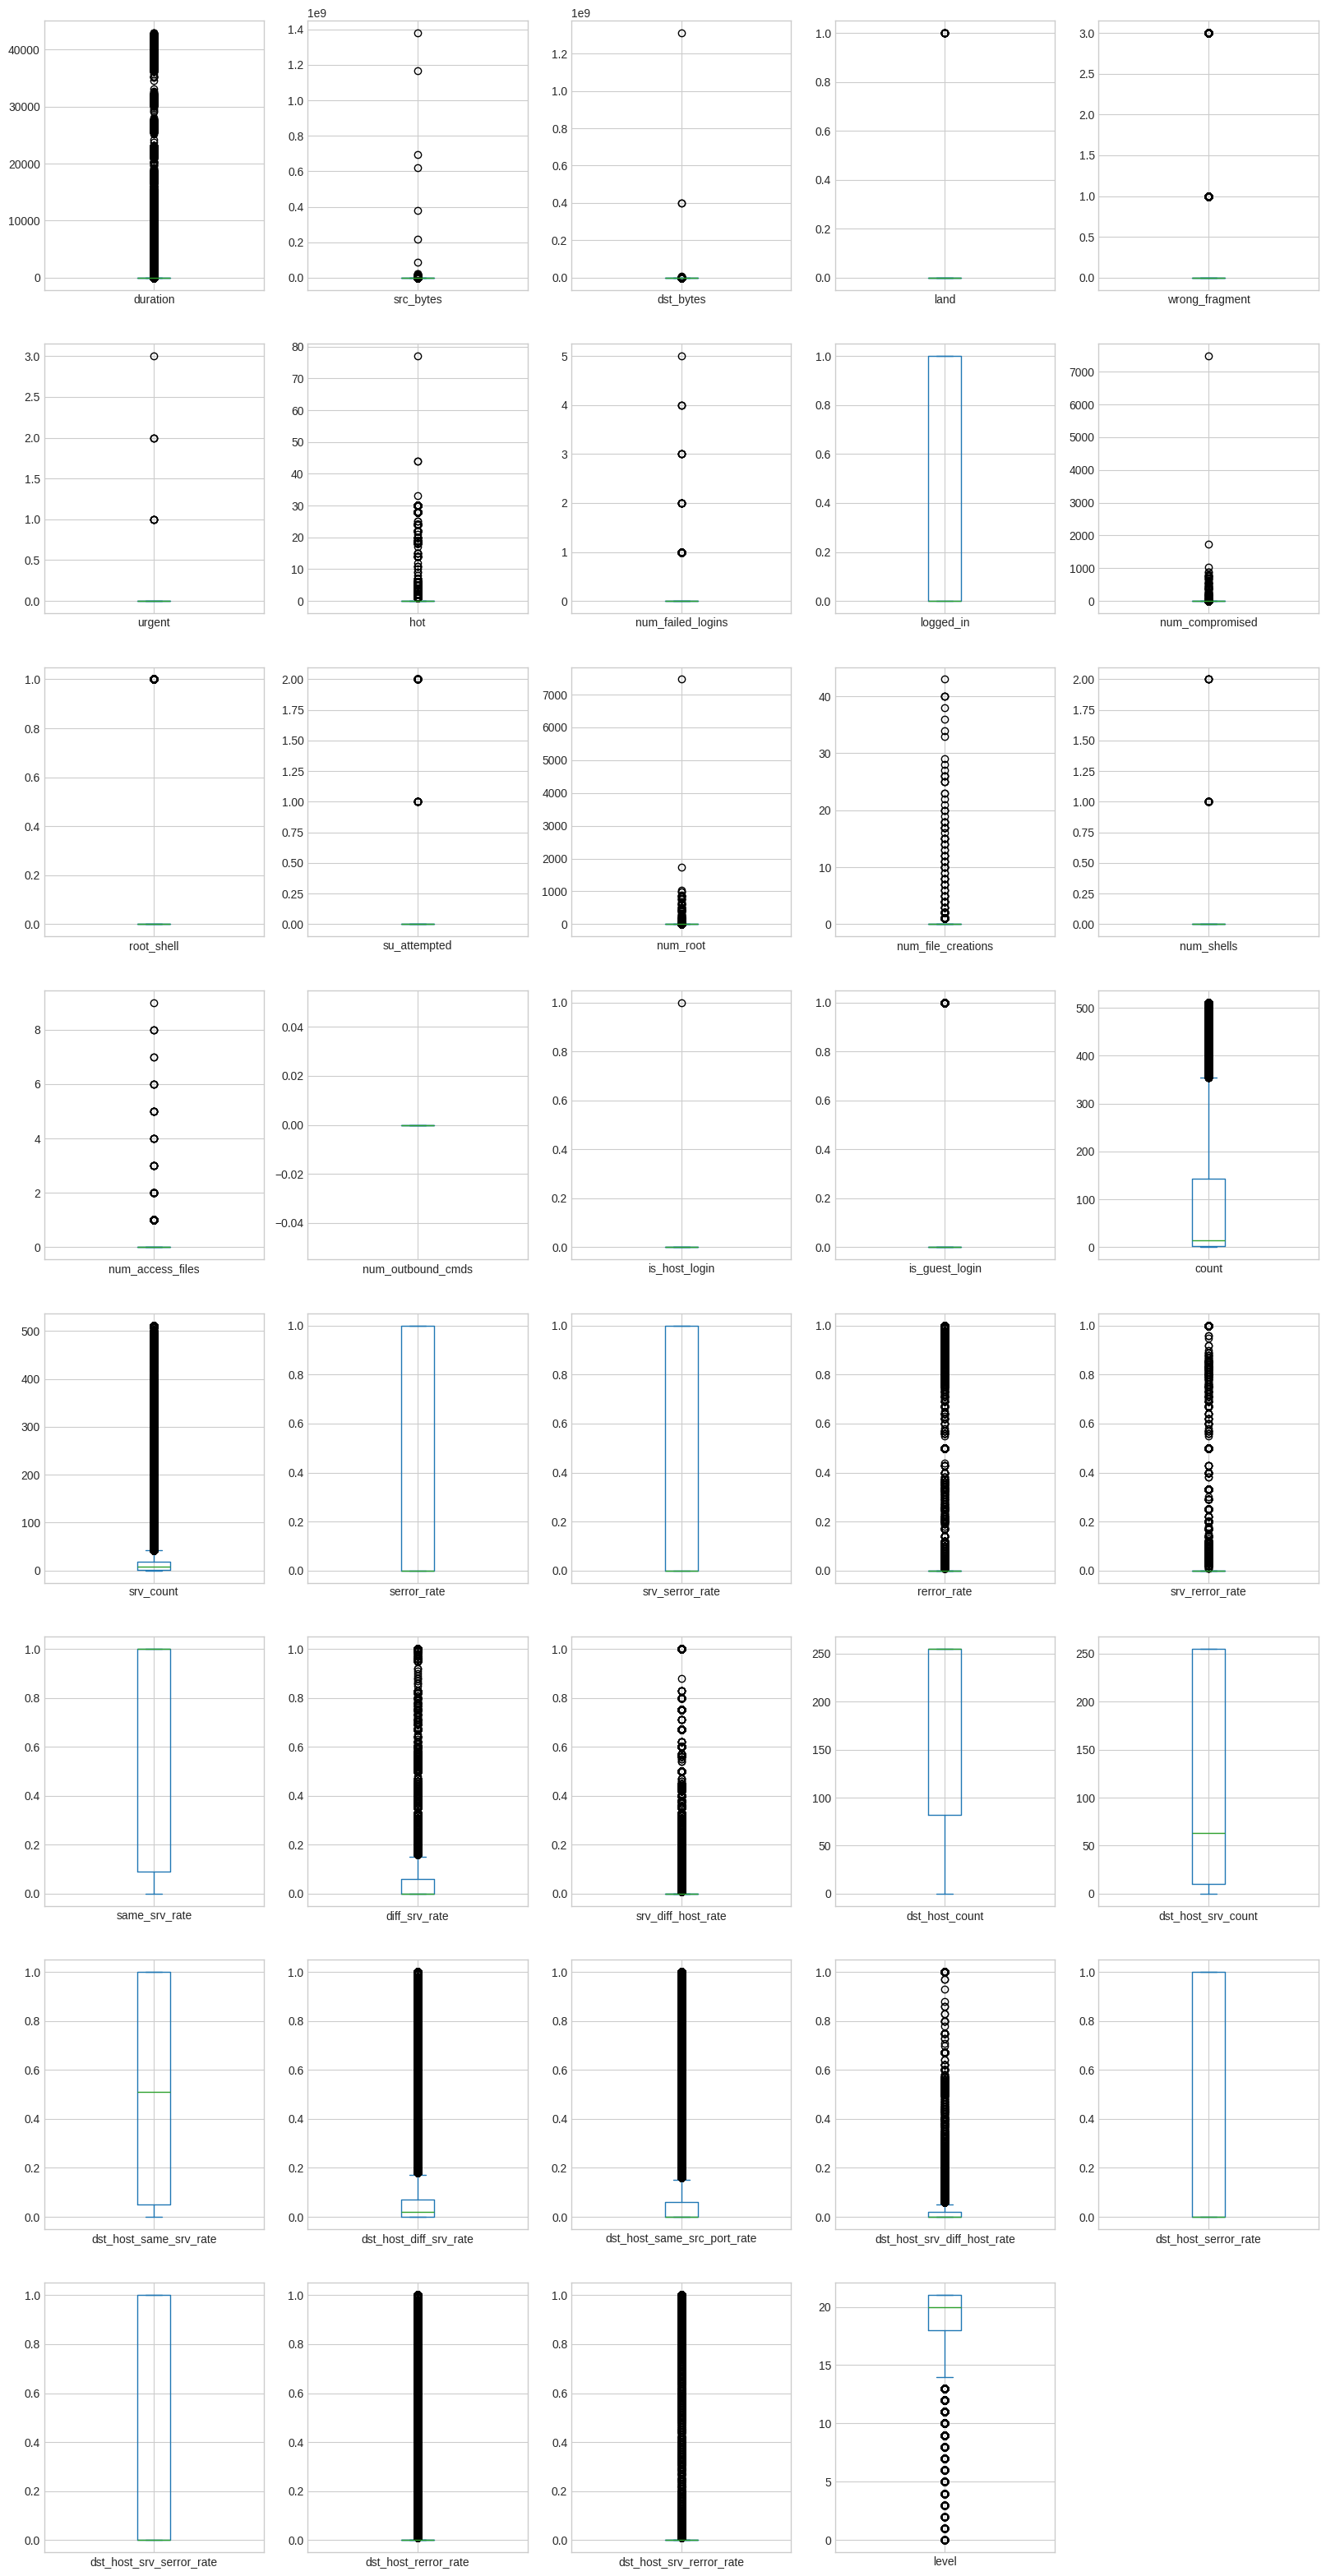

In [126]:
plt.figure(figsize=(20, 40))
data_train.plot(kind='box', subplots=True, layout=(8, 5), figsize=(20, 40))
plt.show()

- **Подтверждение скошенности и выбросов**: Boxplots визуально подтверждают выводы, сделанные из describe(): большинство числовых признаков имеют сильно скошенное распределение и содержат много выбросов.

- **Важность масштабирования**: Различный масштаб и разброс значений подчеркивают важность масштабирования признаков перед обучением моделей, чувствительных к масштабу.

**Нулевая вариативность num_outbound_cmds четко видна, что оправдывает его удаление.**

In [127]:
data_train['num_outbound_cmds'].nunique()

1

In [128]:
data_train = data_train.drop('num_outbound_cmds', axis = 1)

# 4. Преобразование меток

## 4.1 Бинаризация целевой переменной 'anomaly'

In [130]:
data_train['anomaly_bin'] = data_train['anomaly'].apply(lambda x: 'normal' if x == 'normal' else 'anomaly')
data_test['anomaly_bin']  = data_test['anomaly'].apply(lambda x: 'normal' if x == 'normal' else 'anomaly')

In [131]:
label_mapping = {'normal': 0, 'anomaly': 1}
data_train['anomaly'] = data_train['anomaly_bin'].map(label_mapping)
data_test['anomaly'] = data_test['anomaly_bin'].map(label_mapping)

In [132]:
print("Тренировочный датасет после бинарного распределения:")
print(data_train['anomaly'].value_counts())
print("\nТестовый датасет после бинарного распределения:")
print(data_test['anomaly'].value_counts())

Тренировочный датасет после бинарного распределения:
anomaly
0    67343
1    58630
Name: count, dtype: int64

Тестовый датасет после бинарного распределения:
anomaly
1    12833
0     9711
Name: count, dtype: int64


## 4.2 Визуализация распределения классов после бинаризации

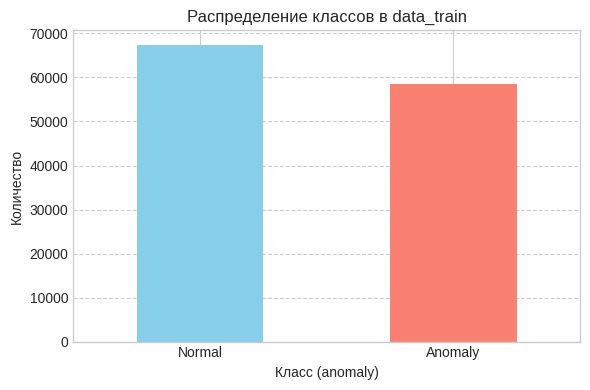

In [133]:
data_train['anomaly'].value_counts().plot(kind='bar', figsize=(6,4), color=['skyblue', 'salmon'])
plt.title('Распределение классов в data_train')
plt.xlabel('Класс (anomaly)')
plt.ylabel('Количество')
plt.xticks(ticks=[0, 1], labels=['Normal', 'Anomaly'], rotation=0)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

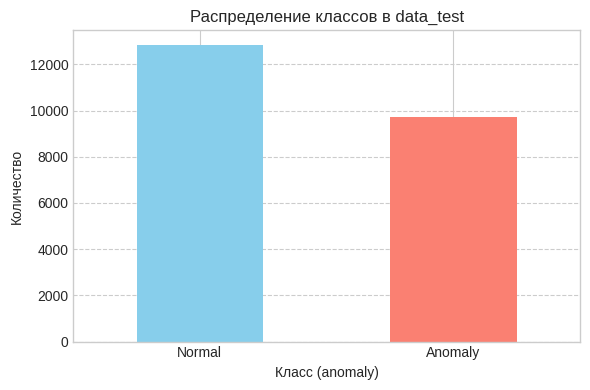

In [134]:
data_test['anomaly'].value_counts().plot(kind='bar', figsize=(6,4), color=['skyblue', 'salmon'])
plt.title('Распределение классов в data_test')
plt.xlabel('Класс (anomaly)')
plt.ylabel('Количество')
plt.xticks(ticks=[0, 1], labels=['Normal', 'Anomaly'], rotation=0)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# 5. EDA (Exploratory Data Analysis)

## 5.1 Распределение классов

In [135]:
data_train['anomaly'].value_counts(normalize=True)

,proportion
anomaly,
0,0.535
1,0.465


## 5.2 Анализ распределения числовых признаков

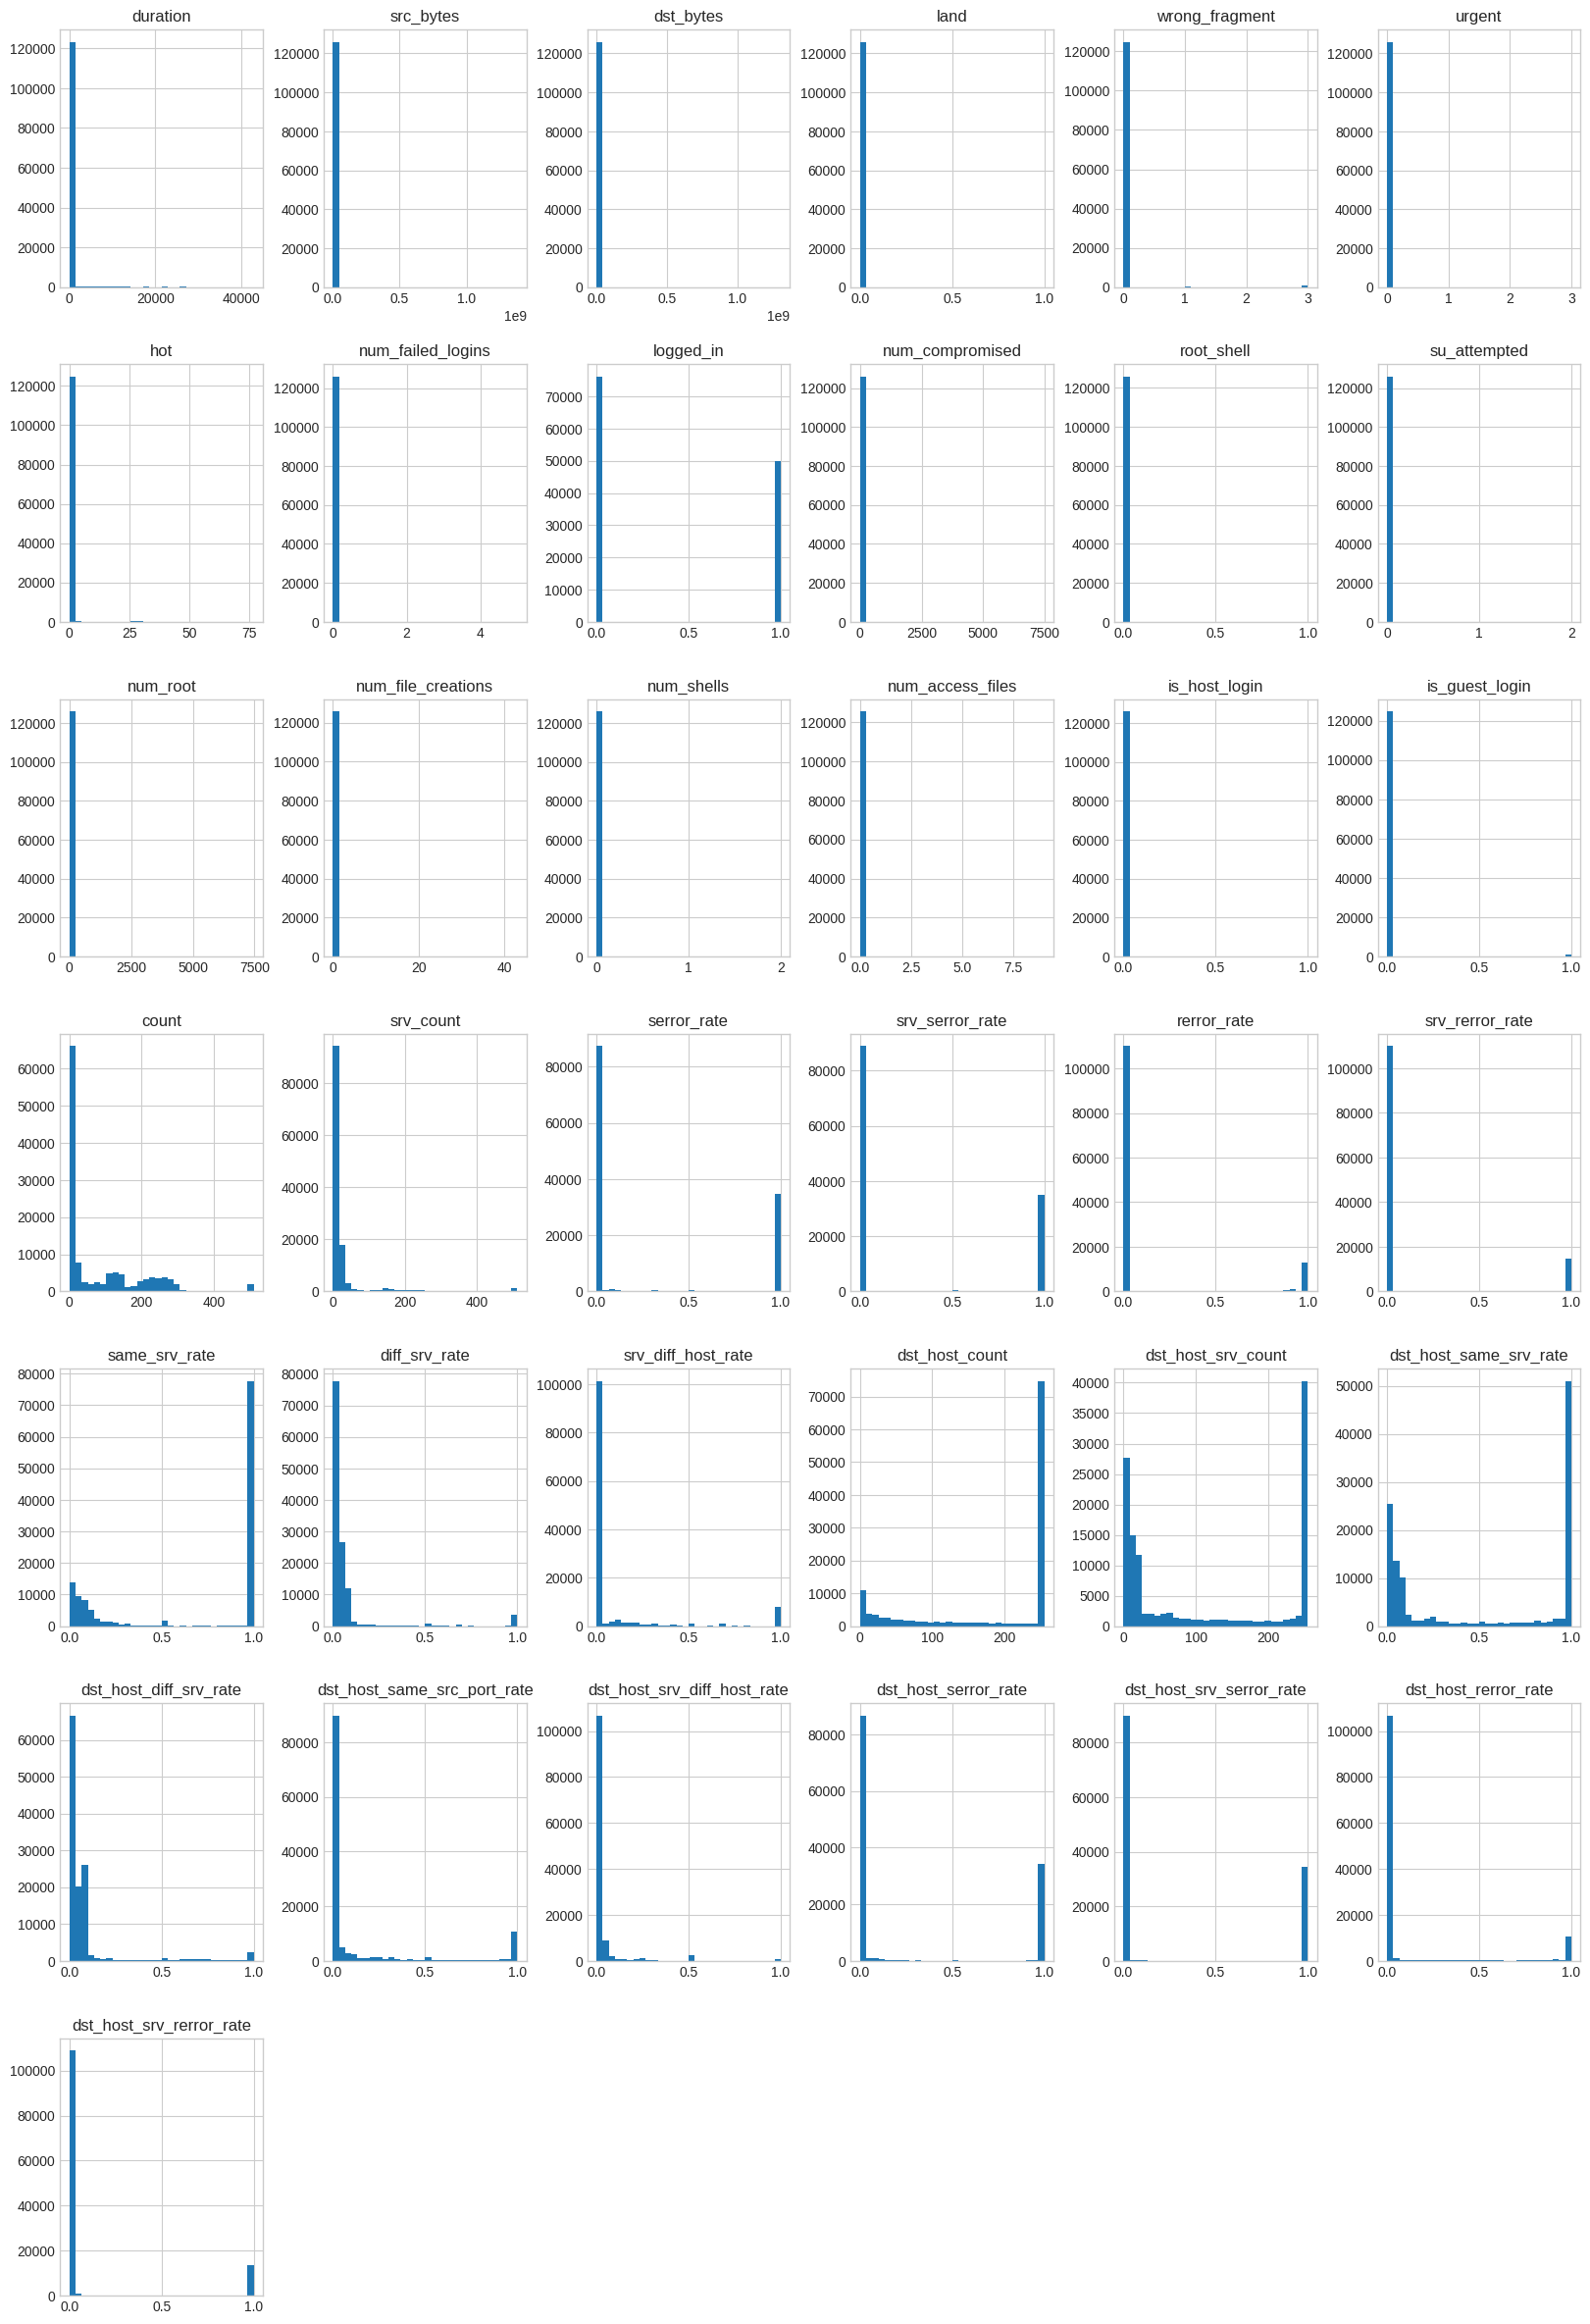

In [137]:
# гистограммы ключевых числовых признаков
num_features = data_train.select_dtypes(include=['int64','float64']).columns.drop(['anomaly','level'])
data_train[num_features].hist(bins=30, figsize=(20,30))
plt.show()

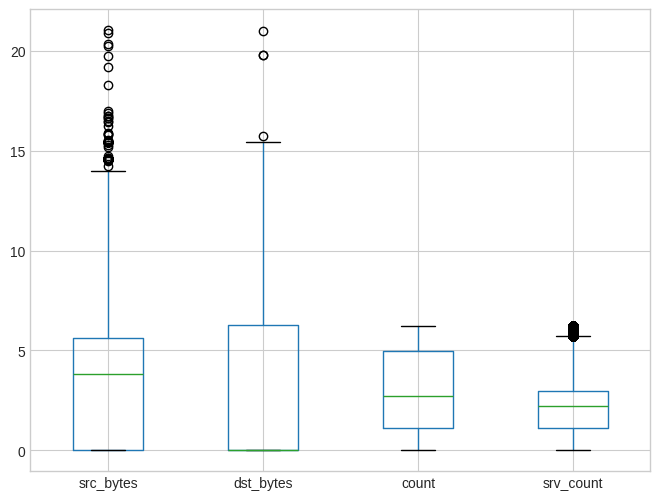

In [138]:
# boxplot для признаков
skewed = ['src_bytes','dst_bytes','count','srv_count']
data_train[skewed].apply(lambda x: np.log1p(x)).boxplot(figsize=(8,6))
plt.show()

## 5.3 Корреляционный анализ числовых признаков

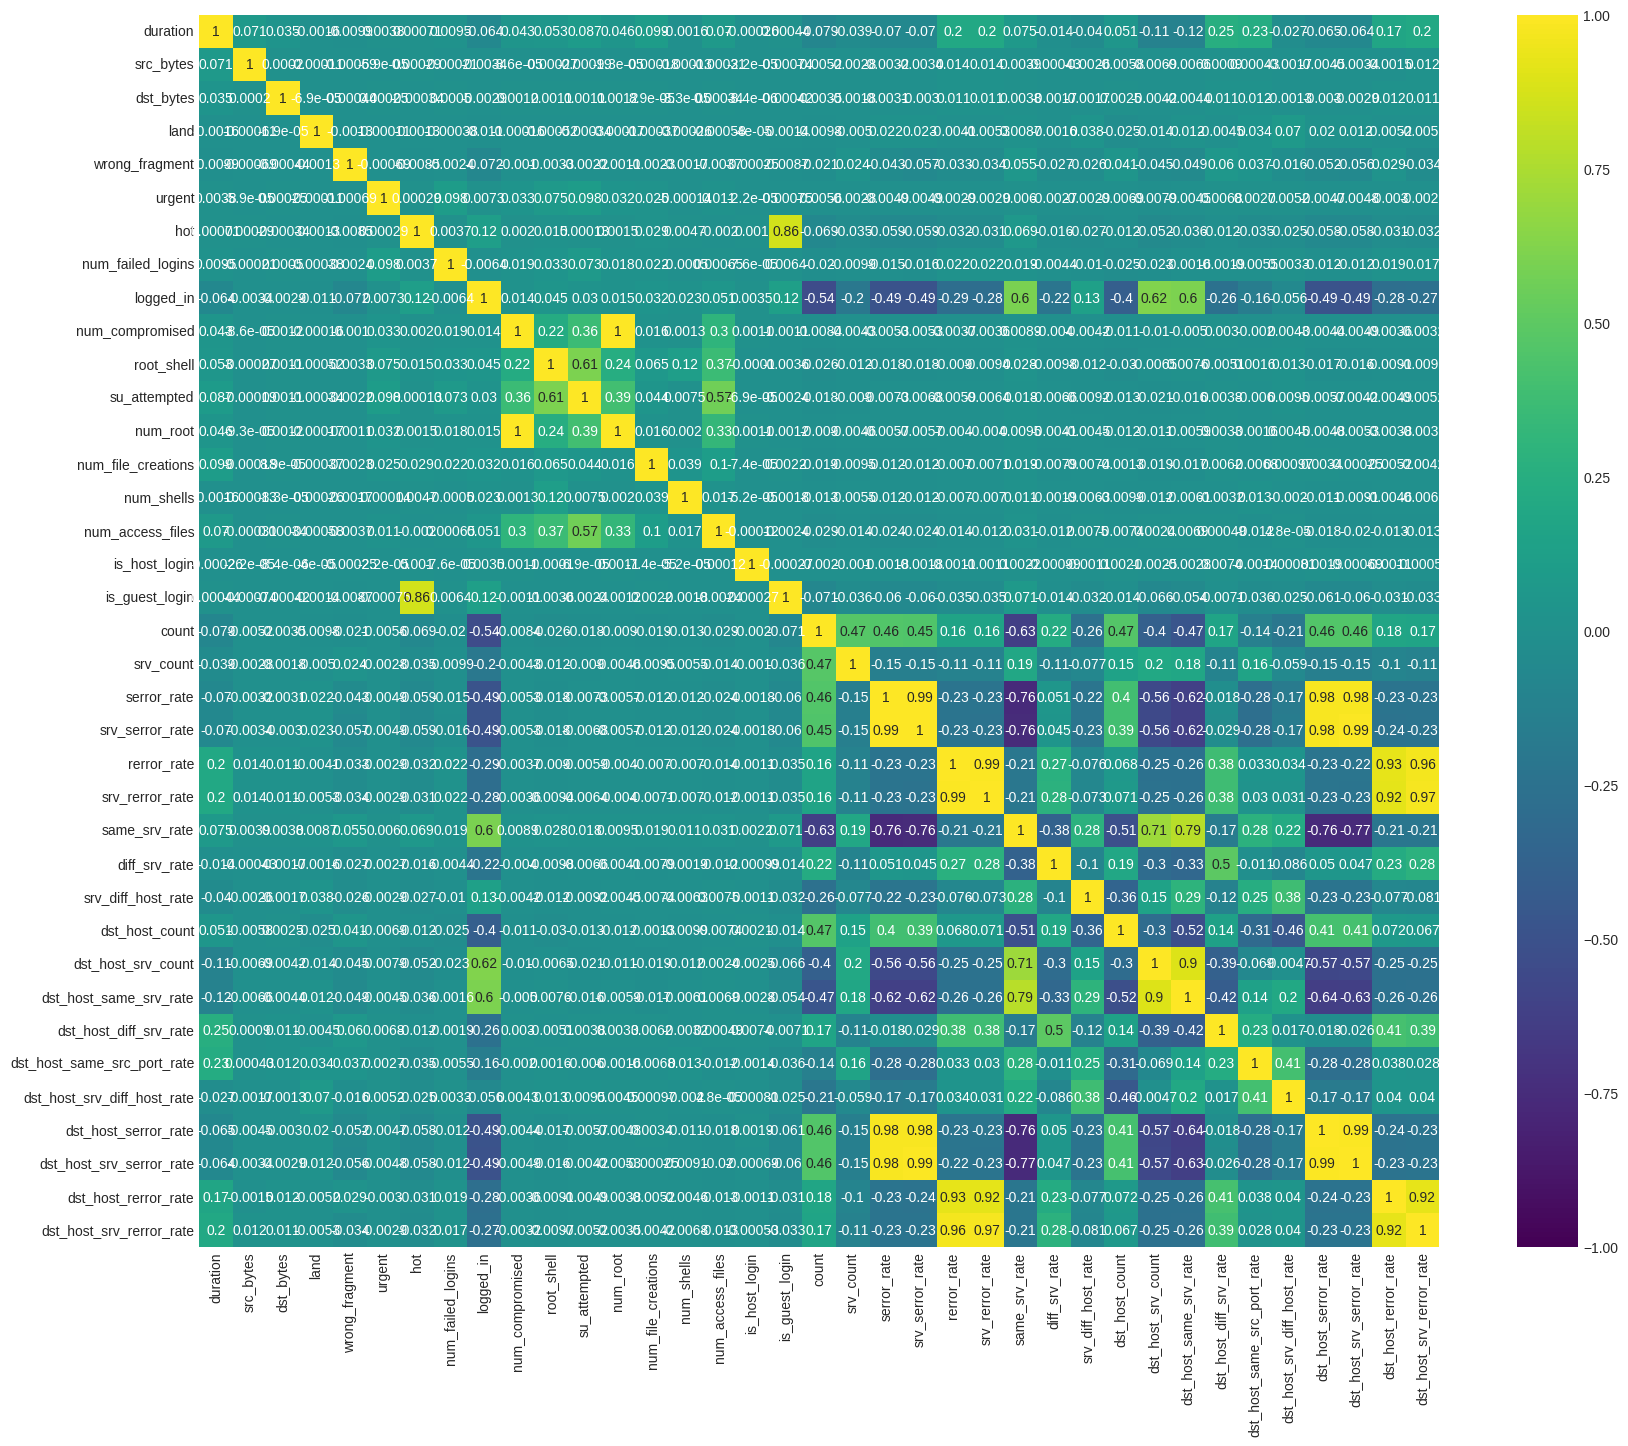

In [ ]:
corr = data_train[num_features].corr()
plt.figure(figsize=(20,16))
sns.heatmap(corr, cmap='viridis', vmax=1, vmin=-1, annot = True)
plt.show()

## 5.4 Анализ категориальных признаков во взаимосвязи с целевой переменной

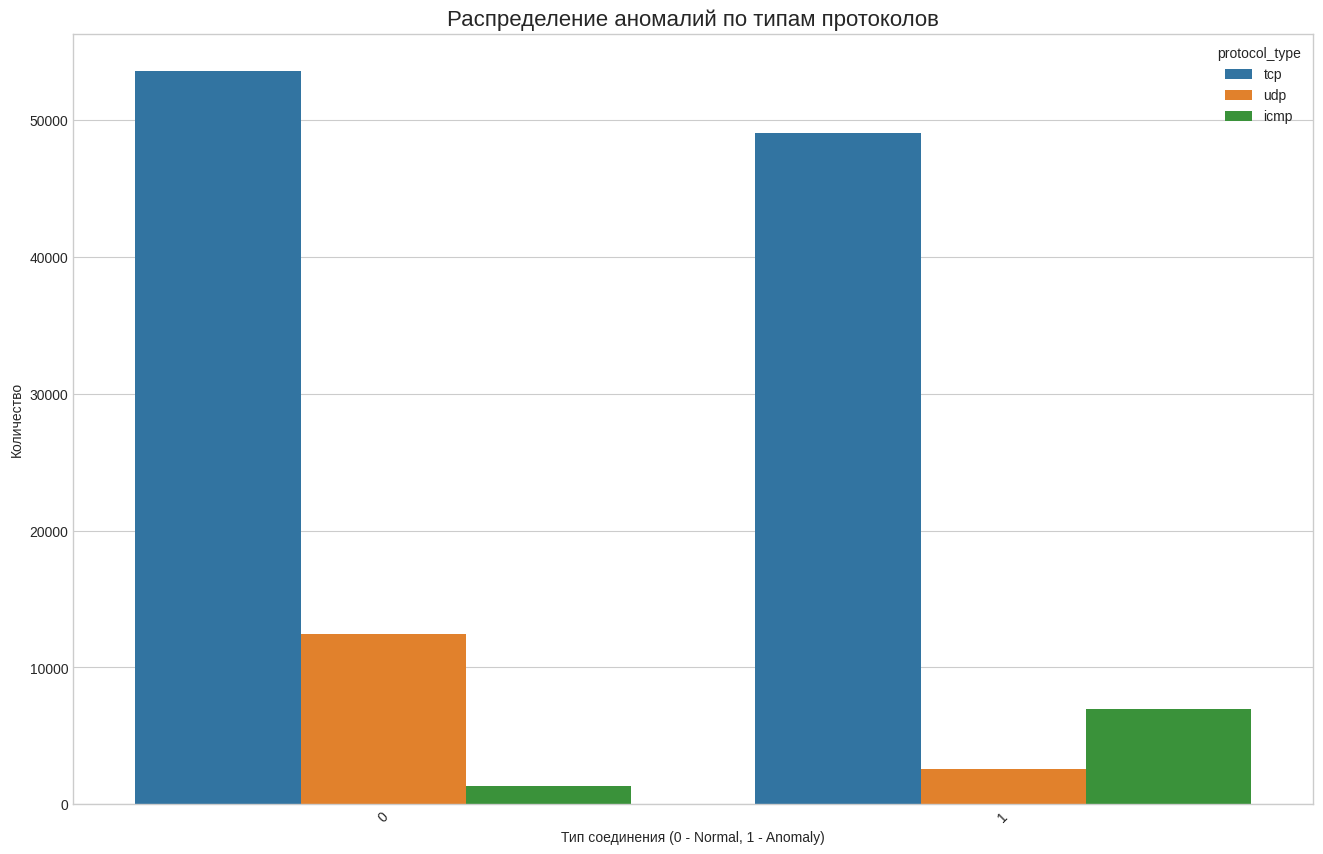

In [139]:
plt.figure(figsize=(16, 10))
sns.countplot(x='anomaly', data=data_train, hue='protocol_type')
plt.xticks(rotation=45)
plt.title('Распределение аномалий по типам протоколов', fontdict={'fontsize': 16})
plt.xlabel('Тип соединения (0 - Normal, 1 - Anomaly)')
plt.ylabel('Количество')
plt.show()

In [140]:
# анализ категориальных признаков
for col in ['protocol_type','service','flag']:
    print(col, data_train[col].value_counts().head(10), '\n')

protocol_type protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64 

service service
http        40338
private     21853
domain_u     9043
smtp         7313
ftp_data     6860
eco_i        4586
other        4359
ecr_i        3077
telnet       2353
finger       1767
Name: count, dtype: int64 

flag flag
SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
Name: count, dtype: int64 



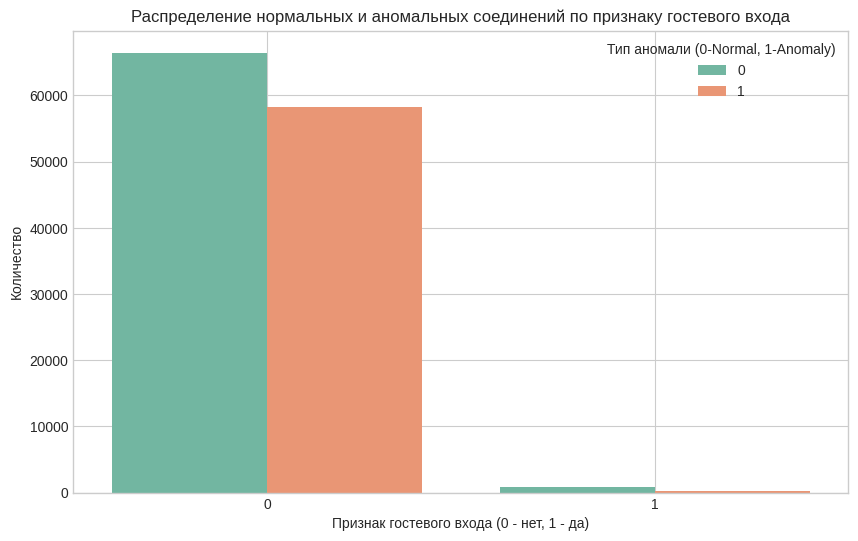

In [142]:
plt.figure(figsize=(10, 6))
sns.countplot(x='is_guest_login', hue='anomaly', data=data_train, palette='Set2')
plt.xlabel('Признак гостевого входа (0 - нет, 1 - да)')
plt.ylabel('Количество') #
plt.title('Распределение нормальных и аномальных соединений по признаку гостевого входа')
plt.legend(title='Тип аномали (0-Normal, 1-Anomaly)')
plt.grid(True)
plt.show()

# 6. Формирование препроцессинга

In [143]:
data_train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,anomaly,level,anomaly_bin
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.000,0.000,0.000,0.000,1.000,0.000,0.000,150,25,0.170,0.030,0.170,0.000,0.000,0.000,0.050,0.000,0,20,normal
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.000,0.000,0.000,0.000,0.080,0.150,0.000,255,1,0.000,0.600,0.880,0.000,0.000,0.000,0.000,0.000,0,15,normal
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.000,1.000,0.000,0.000,0.050,0.070,0.000,255,26,0.100,0.050,0.000,0.000,1.000,1.000,0.000,0.000,1,19,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,5,5,0.200,0.200,0.000,0.000,1.000,0.000,0.000,30,255,1.000,0.000,0.030,0.040,0.030,0.010,0.000,0.010,0,21,normal
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,30,32,0.000,0.000,0.000,0.000,1.000,0.000,0.090,255,255,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,21,normal


## 6.1 Создание препроцессора (ColumnTransformer: OneHotEncoder, StandardScaler)

In [144]:
cat_features = ['protocol_type', 'service', 'flag']
cat_features

['protocol_type', 'service', 'flag']

In [145]:
num_features = [c for c in data_train.columns
                if c not in cat_features + ['anomaly', 'anomaly_bin', 'level']]
num_features

['duration',
 'src_bytes',
 'dst_bytes',
 'land',
 'wrong_fragment',
 'urgent',
 'hot',
 'num_failed_logins',
 'logged_in',
 'num_compromised',
 'root_shell',
 'su_attempted',
 'num_root',
 'num_file_creations',
 'num_shells',
 'num_access_files',
 'is_host_login',
 'is_guest_login',
 'count',
 'srv_count',
 'serror_rate',
 'srv_serror_rate',
 'rerror_rate',
 'srv_rerror_rate',
 'same_srv_rate',
 'diff_srv_rate',
 'srv_diff_host_rate',
 'dst_host_count',
 'dst_host_srv_count',
 'dst_host_same_srv_rate',
 'dst_host_diff_srv_rate',
 'dst_host_same_src_port_rate',
 'dst_host_srv_diff_host_rate',
 'dst_host_serror_rate',
 'dst_host_srv_serror_rate',
 'dst_host_rerror_rate',
 'dst_host_srv_rerror_rate']

In [146]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
    ('num', StandardScaler(), num_features)
])

## 6.2 Разделение данных на обучающую и валидационную выборки (X_train, X_val)

In [147]:
X = data_train.drop(['anomaly', 'anomaly_bin', 'level'], axis=1)
y = data_train['anomaly']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)


## 6.3 Анализ важности признаков после базового препроцессинга (Mutual Information)

In [148]:
X_train_processed_temp = preprocessor.fit_transform(X_train)
feature_names_processed = preprocessor.get_feature_names_out()

mi_scores = mutual_info_classif(X_train_processed_temp, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=feature_names_processed).sort_values(ascending=False)
print(mi_series.head(40))

num__src_bytes                     0.565
num__dst_bytes                     0.439
num__diff_srv_rate                 0.363
num__same_srv_rate                 0.358
cat__flag_SF                       0.339
num__dst_host_srv_count            0.333
num__dst_host_same_srv_rate        0.309
num__dst_host_serror_rate          0.289
num__logged_in                     0.288
num__dst_host_diff_srv_rate        0.287
num__dst_host_srv_serror_rate      0.282
num__serror_rate                   0.281
num__srv_serror_rate               0.271
num__count                         0.267
cat__flag_S0                       0.261
cat__service_http                  0.194
num__dst_host_srv_diff_host_rate   0.191
num__dst_host_count                0.140
num__dst_host_same_src_port_rate   0.133
cat__service_private               0.120
num__srv_diff_host_rate            0.099
num__srv_count                     0.065
num__dst_host_srv_rerror_rate      0.064
cat__service_domain_u              0.048
num__rerror_rate

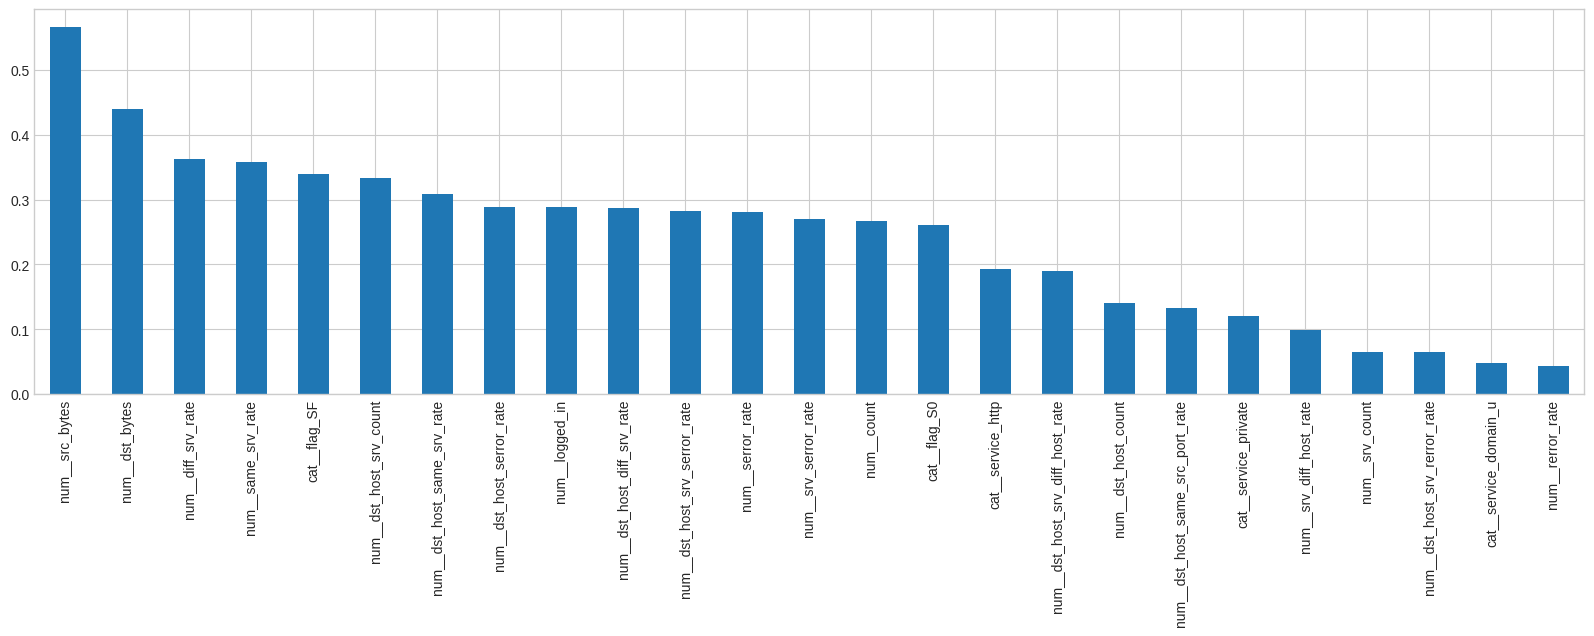

In [149]:
mi_series.head(25).plot.bar(figsize=(20, 5))
plt.show()

num_src_bytes (и его отмасштабированная версия num__src_bytes) занимает топ-1 место по взаимной информации, потому что объем данных, передаваемых от источника, является очень показательной характеристикой, которая часто и значительно отличается при нормальной сетевой активности и при различных видах атак. Это делает его одним из самых ценных признаков для построения модели обнаружения аномалий.

Аналогично и для num__dst_bytes (количество байт к получателю), который на втором месте – он также несет много информации по схожим причинам. Часто аномальная активность изменяет и объем входящего, и объем исходящего трафика.

# 7. Постройка моделей

## 7.1 Логистичнская регрессия

In [ ]:
model_lr = Pipeline([
    ('preproc', preprocessor),
    ('clf', LogisticRegression(max_iter=1000))
])

param_grid_lr = [
    {
        'clf__solver': ['liblinear'],
        'clf__C': [0.1, 1, 10, 100]
    }]

gs_lr = GridSearchCV(model_lr, param_grid_lr,
                     cv=5, scoring='roc_auc', n_jobs=-1, return_train_score=True)

start_time_lr = time.time()
gs_lr.fit(X_train, y_train)
end_time_lr = time.time()
training_time_lr = end_time_lr - start_time_lr
print(f"Лучший ROC AUC на кросс-валидации: {gs_lr.best_score_:.4f}")
print(f"Лучшие параметры: {gs_lr.best_params_}")
print(f"Общее время подбора гиперпараметров (GridSearchCV): {training_time_lr:.2f} сек")

Лучший ROC AUC на кросс-валидации: 0.9965
Лучшие параметры: {'clf__C': 100, 'clf__solver': 'liblinear'}
Общее время подбора гиперпараметров (GridSearchCV): 377.68 сек


In [ ]:
# Оценка лучшей модели на валидационном наборе
best_lr_model = gs_lr.best_estimator_
y_val_pred_lr = best_lr_model.predict(X_val)
y_val_proba_lr = best_lr_model.predict_proba(X_val)[:, 1]
print(roc_auc_score(y_val, y_val_proba_lr))

0.9965441551404938


In [ ]:
print(classification_report(y_val, y_val_pred_lr, target_names=['Normal (0)', 'Anomaly (1)']))

              precision    recall  f1-score   support

  Normal (0)       0.97      0.98      0.98      6735
 Anomaly (1)       0.98      0.97      0.97      5863

    accuracy                           0.97     12598
   macro avg       0.97      0.97      0.97     12598
weighted avg       0.97      0.97      0.97     12598



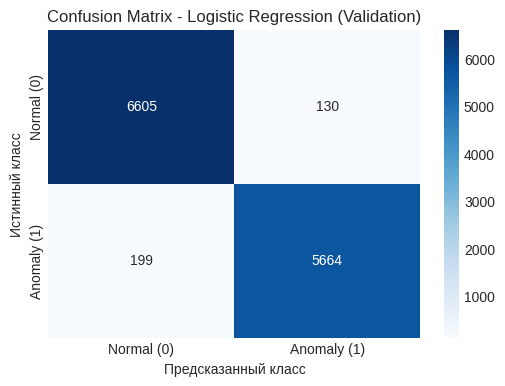

In [ ]:
cm_lr = confusion_matrix(y_val, y_val_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Anomaly (1)'],
            yticklabels=['Normal (0)', 'Anomaly (1)'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Confusion Matrix - Logistic Regression (Validation)')
plt.show()

In [ ]:
best_lr_model

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['protocol_type', 'service',
                                                   'flag']),
                                                 ('num', StandardScaler(),
                                                  ['duration', 'src_bytes',
                                                   'dst_bytes', 'land',
                                                   'wrong_fragment', 'urgent',
                                                   'hot', 'num_failed_logins',
                                                   'logged_in',
                                                   'num_compromised',
                                                   'root_shell', 'su_attempted',
                                                   'num_root',
                                                   '...ations',
                                                   'num_shells',
                                                   'num_access_files',
                                                   'is_host_login',
                                                   'is_guest_login', 'count',
                                                   'srv_count', 'serror_rate',
                                                   'srv_serror_rate',
                                                   'rerror_rate',
                                                   'srv_rerror_rate',
                                                   'same_srv_rate',
                                                   'diff_srv_rate',
                                                   'srv_diff_host_rate',
                                                   'dst_host_count',
                                                   'dst_host_srv_count',
                                                   'dst_host_same_srv_rate', ...])])),
                ('clf',
                 LogisticRegression(C=100, max_iter=1000, solver='liblinear'))])

In [ ]:
if 'results_summary' not in globals():
    results_summary = {}

In [ ]:
val_roc_auc_lr = roc_auc_score(y_val, y_val_proba_lr)
val_f1_anomaly_lr = f1_score(y_val, y_val_pred_lr, pos_label=1)
results_summary['LogisticRegression'] = {
    'best_cv_roc_auc': gs_lr.best_score_,
    'best_params': gs_lr.best_params_,
    'val_roc_auc': val_roc_auc_lr,
    'val_f1_anomaly': val_f1_anomaly_lr,
    'training_time_total_gs': training_time_lr,
    'estimator': best_lr_model
}

In [ ]:
models_dir = "saved_models"
os.makedirs(models_dir, exist_ok=True)

model_filename_lr = os.path.join(models_dir, "best_logistic_regression_pipeline.joblib")
joblib.dump(best_lr_model, model_filename_lr)

['saved_models/best_logistic_regression_pipeline.joblib']

## 7.2 Наивный Байес (GaussianNB)

In [ ]:
model_nb = Pipeline([
    ('preproc', preprocessor),
    ('clf', GaussianNB())
])

param_grid_nb = {
    'clf__var_smoothing': np.logspace(-9, -2, 8)
}

gs_nb = GridSearchCV(model_nb, param_grid_nb, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                     scoring='roc_auc',n_jobs=-1,return_train_score=True)

start_time_nb = time.time()
gs_nb.fit(X_train, y_train)
end_time_nb = time.time()
training_time_nb = end_time_nb - start_time_nb
print(f"Лучший ROC AUC на кросс-валидации: {gs_nb.best_score_:.4f}")
print(f"Лучшие параметры: {gs_nb.best_params_}")
print(f"Общее время подбора гиперпараметров (GridSearchCV): {training_time_nb:.2f} сек")

Лучший ROC AUC на кросс-валидации: 0.9797
Лучшие параметры: {'clf__var_smoothing': np.float64(0.0001)}
Общее время подбора гиперпараметров (GridSearchCV): 18.71 сек


In [ ]:
best_nb_model = gs_nb.best_estimator_
y_val_pred_nb = best_nb_model.predict(X_val)
y_val_proba_nb = best_nb_model.predict_proba(X_val)[:, 1]
print(roc_auc_score(y_val, y_val_proba_nb))

0.9806490339110254


In [ ]:
print(classification_report(y_val, y_val_pred_nb, target_names=['Normal (0)', 'Anomaly (1)']))

              precision    recall  f1-score   support

  Normal (0)       0.90      0.98      0.94      6735
 Anomaly (1)       0.98      0.87      0.92      5863

    accuracy                           0.93     12598
   macro avg       0.94      0.93      0.93     12598
weighted avg       0.94      0.93      0.93     12598



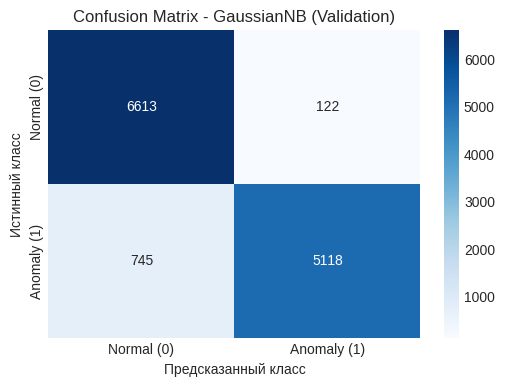

In [ ]:
cm_nb = confusion_matrix(y_val, y_val_pred_nb)
plt.figure(figsize=(6,4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Anomaly (1)'],
            yticklabels=['Normal (0)', 'Anomaly (1)'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Confusion Matrix - GaussianNB (Validation)')
plt.show()

In [ ]:
best_nb_model

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['protocol_type', 'service',
                                                   'flag']),
                                                 ('num', StandardScaler(),
                                                  ['duration', 'src_bytes',
                                                   'dst_bytes', 'land',
                                                   'wrong_fragment', 'urgent',
                                                   'hot', 'num_failed_logins',
                                                   'logged_in',
                                                   'num_compromised',
                                                   'root_shell', 'su_attempted',
                                                   'num_root',
                                                   'num_file_creations',
                                                   'num_shells',
                                                   'num_access_files',
                                                   'is_host_login',
                                                   'is_guest_login', 'count',
                                                   'srv_count', 'serror_rate',
                                                   'srv_serror_rate',
                                                   'rerror_rate',
                                                   'srv_rerror_rate',
                                                   'same_srv_rate',
                                                   'diff_srv_rate',
                                                   'srv_diff_host_rate',
                                                   'dst_host_count',
                                                   'dst_host_srv_count',
                                                   'dst_host_same_srv_rate', ...])])),
                ('clf', GaussianNB(var_smoothing=np.float64(0.0001)))])

In [ ]:
val_roc_auc_nb = roc_auc_score(y_val, y_val_proba_nb)
val_f1_anomaly_nb = f1_score(y_val, y_val_pred_nb, pos_label=1)
results_summary['GaussianNB'] = {
    'best_cv_roc_auc': gs_nb.best_score_,
    'best_params': gs_nb.best_params_,
    'val_roc_auc': val_roc_auc_nb,
    'val_f1_anomaly': val_f1_anomaly_nb,
    'training_time_total_gs': training_time_nb,
    'estimator': best_nb_model
}

In [ ]:
model_filename_nb = os.path.join(models_dir, "best_gaussian_nb_pipeline.joblib")
joblib.dump(best_nb_model, model_filename_nb)

['saved_models/best_gaussian_nb_pipeline.joblib']

## 7.3 Метод опорных векторов (SVM через SGDClassifier)

In [ ]:
model_sgd = Pipeline([
    ('preproc', preprocessor),
    ('clf', SGDClassifier(max_iter=1000, tol=1e-3, random_state=42, early_stopping=True, n_iter_no_change=5, validation_fraction=0.1))
])

param_grid_sgd = {
    'clf__alpha': [1e-5, 1e-4, 1e-3, 1e-2],
    'clf__loss': ['hinge', 'log_loss'],
    'clf__penalty': ['l2', 'l1', 'elasticnet']
}

gs_sgd = GridSearchCV(model_sgd, param_grid_sgd, cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='roc_auc',n_jobs=-1,return_train_score=True
)

start_time_sgd = time.time()
gs_sgd.fit(X_train, y_train)
end_time_sgd = time.time()
training_time_sgd = end_time_sgd - start_time_sgd
print(f"Лучший ROC AUC на кросс-валидации: {gs_sgd.best_score_:.4f}")
print(f"Лучшие параметры: {gs_sgd.best_params_}")
print(f"Общее время подбора гиперпараметров (GridSearchCV): {training_time_sgd:.2f} сек")

Лучший ROC AUC на кросс-валидации: 0.9950
Лучшие параметры: {'clf__alpha': 0.0001, 'clf__loss': 'log_loss', 'clf__penalty': 'elasticnet'}
Общее время подбора гиперпараметров (GridSearchCV): 40.28 сек


In [ ]:
best_sgd_model = gs_sgd.best_estimator_
y_val_pred_sgd = best_sgd_model.predict(X_val)

In [ ]:
if hasattr(best_sgd_model.named_steps['clf'], "predict_proba"):
    y_val_proba_sgd = best_sgd_model.predict_proba(X_val)[:, 1]
    val_roc_auc_sgd = roc_auc_score(y_val, y_val_proba_sgd)
elif hasattr(best_sgd_model.named_steps['clf'], "decision_function"):
    y_val_decision_sgd = best_sgd_model.decision_function(X_val)
    val_roc_auc_sgd = roc_auc_score(y_val, y_val_decision_sgd)
else:
    val_roc_auc_sgd = float('nan')

val_f1_anomaly_sgd = f1_score(y_val, y_val_pred_sgd, pos_label=1)

In [ ]:
print(f"ROC AUC: {val_roc_auc_sgd:.4f}")

ROC AUC: 0.9957


In [ ]:
print(classification_report(y_val, y_val_pred_sgd, target_names=['Normal (0)', 'Anomaly (1)']))

              precision    recall  f1-score   support

  Normal (0)       0.96      0.98      0.97      6735
 Anomaly (1)       0.98      0.95      0.97      5863

    accuracy                           0.97     12598
   macro avg       0.97      0.97      0.97     12598
weighted avg       0.97      0.97      0.97     12598



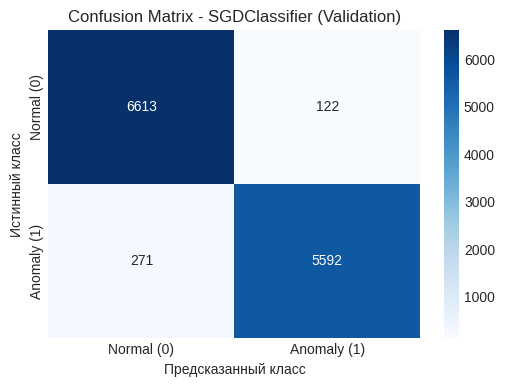

In [ ]:
cm_sgd = confusion_matrix(y_val, y_val_pred_sgd)
plt.figure(figsize=(6,4))
sns.heatmap(cm_sgd, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Anomaly (1)'],
            yticklabels=['Normal (0)', 'Anomaly (1)'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Confusion Matrix - SGDClassifier (Validation)')
plt.show()

In [ ]:
best_sgd_model

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['protocol_type', 'service',
                                                   'flag']),
                                                 ('num', StandardScaler(),
                                                  ['duration', 'src_bytes',
                                                   'dst_bytes', 'land',
                                                   'wrong_fragment', 'urgent',
                                                   'hot', 'num_failed_logins',
                                                   'logged_in',
                                                   'num_compromised',
                                                   'root_shell', 'su_attempted',
                                                   'num_root',
                                                   '...
                                                   'num_access_files',
                                                   'is_host_login',
                                                   'is_guest_login', 'count',
                                                   'srv_count', 'serror_rate',
                                                   'srv_serror_rate',
                                                   'rerror_rate',
                                                   'srv_rerror_rate',
                                                   'same_srv_rate',
                                                   'diff_srv_rate',
                                                   'srv_diff_host_rate',
                                                   'dst_host_count',
                                                   'dst_host_srv_count',
                                                   'dst_host_same_srv_rate', ...])])),
                ('clf',
                 SGDClassifier(early_stopping=True, loss='log_loss',
                               penalty='elasticnet', random_state=42))])

In [ ]:
results_summary['SGDClassifier'] = {
    'best_cv_roc_auc': gs_sgd.best_score_,
    'best_params': gs_sgd.best_params_,
    'val_roc_auc': val_roc_auc_sgd,
    'val_f1_anomaly': val_f1_anomaly_sgd,
    'training_time_total_gs': training_time_sgd,
    'estimator': best_sgd_model
}

In [ ]:
model_filename_sgd = os.path.join(models_dir, "best_sgd_classifier_pipeline.joblib")
joblib.dump(best_sgd_model, model_filename_sgd)

['saved_models/best_sgd_classifier_pipeline.joblib']

## 7.4 Случайный лес (Random Forest)

In [ ]:
model_rf = Pipeline([
    ('preproc', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    'clf__n_estimators': [50, 100],
    'clf__max_depth': [10, 20, None],
    'clf__min_samples_split': [2, 5],
    'clf__min_samples_leaf': [1, 2]
}

gs_rf = GridSearchCV(model_rf, param_grid_rf,cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1,return_train_score=True
)

start_time_rf = time.time()
gs_rf.fit(X_train, y_train)
end_time_rf = time.time()
training_time_rf = end_time_rf - start_time_rf
print(f"Лучший ROC AUC на кросс-валидации: {gs_rf.best_score_:.4f}")
print(f"Лучшие параметры: {gs_rf.best_params_}")
print(f"Общее время подбора гиперпараметров (GridSearchCV): {training_time_rf:.2f} сек")

Лучший ROC AUC на кросс-валидации: 1.0000
Лучшие параметры: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
Общее время подбора гиперпараметров (GridSearchCV): 279.71 сек


In [ ]:
best_rf_model = gs_rf.best_estimator_
y_val_pred_rf = best_rf_model.predict(X_val)
y_val_proba_rf = best_rf_model.predict_proba(X_val)[:, 1]
print(roc_auc_score(y_val, y_val_proba_rf))

0.999999113639181


In [ ]:
print(classification_report(y_val, y_val_pred_rf, target_names=['Normal (0)', 'Anomaly (1)']))

              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00      6735
 Anomaly (1)       1.00      1.00      1.00      5863

    accuracy                           1.00     12598
   macro avg       1.00      1.00      1.00     12598
weighted avg       1.00      1.00      1.00     12598



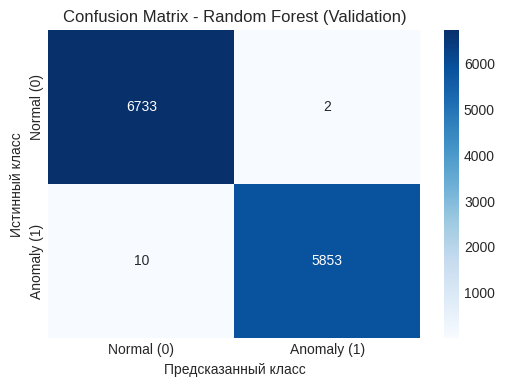

In [ ]:
cm_rf = confusion_matrix(y_val, y_val_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Anomaly (1)'],
            yticklabels=['Normal (0)', 'Anomaly (1)'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Confusion Matrix - Random Forest (Validation)')
plt.show()

In [ ]:
best_rf_model

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['protocol_type', 'service',
                                                   'flag']),
                                                 ('num', StandardScaler(),
                                                  ['duration', 'src_bytes',
                                                   'dst_bytes', 'land',
                                                   'wrong_fragment', 'urgent',
                                                   'hot', 'num_failed_logins',
                                                   'logged_in',
                                                   'num_compromised',
                                                   'root_shell', 'su_attempted',
                                                   'num_root',
                                                   '...tions',
                                                   'num_shells',
                                                   'num_access_files',
                                                   'is_host_login',
                                                   'is_guest_login', 'count',
                                                   'srv_count', 'serror_rate',
                                                   'srv_serror_rate',
                                                   'rerror_rate',
                                                   'srv_rerror_rate',
                                                   'same_srv_rate',
                                                   'diff_srv_rate',
                                                   'srv_diff_host_rate',
                                                   'dst_host_count',
                                                   'dst_host_srv_count',
                                                   'dst_host_same_srv_rate', ...])])),
                ('clf',
                 RandomForestClassifier(min_samples_split=5, random_state=42))])

In [ ]:
val_roc_auc_rf = roc_auc_score(y_val, y_val_proba_rf)
val_f1_anomaly_rf = f1_score(y_val, y_val_pred_rf, pos_label=1)
results_summary['RandomForest'] = {
    'best_cv_roc_auc': gs_rf.best_score_,
    'best_params': gs_rf.best_params_,
    'val_roc_auc': val_roc_auc_rf,
    'val_f1_anomaly': val_f1_anomaly_rf,
    'training_time_total_gs': training_time_rf,
    'estimator': best_rf_model
}

In [ ]:
model_filename_rf = os.path.join(models_dir, "best_random_forest_pipeline.joblib")
joblib.dump(best_rf_model, model_filename_rf)

['saved_models/best_random_forest_pipeline.joblib']

## 7.5 XGBoost.

In [ ]:
model_xgb = Pipeline([
    ('preproc', preprocessor),
    ('clf', xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42,))
])


param_grid_xgb = {
    'clf__n_estimators': [50, 100],
    'clf__max_depth': [3, 5, 7],
    'clf__learning_rate': [0.05, 0.1, 0.2],
    'clf__subsample': [0.7, 1.0],
    'clf__colsample_bytree': [0.7, 1.0]
}

gs_xgb = GridSearchCV(model_xgb, param_grid_xgb,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1, return_train_score=True
)

start_time_xgb = time.time()
gs_xgb.fit(X_train, y_train)
end_time_xgb = time.time()
training_time_xgb = end_time_xgb - start_time_xgb
print(f"Лучший ROC AUC на кросс-валидации: {gs_xgb.best_score_:.4f}")
print(f"Лучшие параметры: {gs_xgb.best_params_}")
print(f"Общее время подбора гиперпараметров (GridSearchCV): {training_time_xgb:.2f} сек")

Лучший ROC AUC на кросс-валидации: 1.0000
Лучшие параметры: {'clf__colsample_bytree': 0.7, 'clf__learning_rate': 0.2, 'clf__max_depth': 7, 'clf__n_estimators': 100, 'clf__subsample': 1.0}
Общее время подбора гиперпараметров (GridSearchCV): 375.05 сек


In [ ]:
best_xgb_model = gs_xgb.best_estimator_
y_val_pred_xgb = best_xgb_model.predict(X_val)
y_val_proba_xgb = best_xgb_model.predict_proba(X_val)[:, 1]
print(roc_auc_score(y_val, y_val_proba_xgb))

0.9999993922097241


In [ ]:
print(classification_report(y_val, y_val_pred_xgb, target_names=['Normal (0)', 'Anomaly (1)']))

              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00      6735
 Anomaly (1)       1.00      1.00      1.00      5863

    accuracy                           1.00     12598
   macro avg       1.00      1.00      1.00     12598
weighted avg       1.00      1.00      1.00     12598



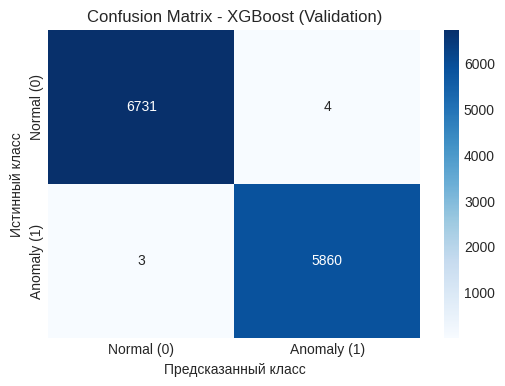

In [ ]:
cm_xgb = confusion_matrix(y_val, y_val_pred_xgb)
plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Anomaly (1)'],
            yticklabels=['Normal (0)', 'Anomaly (1)'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Confusion Matrix - XGBoost (Validation)')
plt.show()

In [ ]:
best_xgb_model

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['protocol_type', 'service',
                                                   'flag']),
                                                 ('num', StandardScaler(),
                                                  ['duration', 'src_bytes',
                                                   'dst_bytes', 'land',
                                                   'wrong_fragment', 'urgent',
                                                   'hot', 'num_failed_logins',
                                                   'logged_in',
                                                   'num_compromised',
                                                   'root_shell', 'su_attempted',
                                                   'num_root',
                                                   '...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.2,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=7, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

In [ ]:
val_roc_auc_xgb = roc_auc_score(y_val, y_val_proba_xgb)
val_f1_anomaly_xgb = f1_score(y_val, y_val_pred_xgb, pos_label=1)
results_summary['XGBoost'] = {
    'best_cv_roc_auc': gs_xgb.best_score_,
    'best_params': gs_xgb.best_params_,
    'val_roc_auc': val_roc_auc_xgb,
    'val_f1_anomaly': val_f1_anomaly_xgb,
    'training_time_total_gs': training_time_xgb,
    'estimator': best_xgb_model
}

In [ ]:
model_filename_xgb = os.path.join(models_dir, "best_xgboost_pipeline.joblib")
joblib.dump(best_xgb_model, model_filename_xgb)

['saved_models/best_xgboost_pipeline.joblib']

## 7.6 Isolation Forest

In [ ]:
# Обучение только на нормальных
X_train_norm = X_train[y_train == 0]
X_train_norm_proc = preprocessor.transform(X_train_norm)
X_val_proc = preprocessor.transform(X_val)

In [ ]:
# contamination = доля аномалий в трейне
contamination = y_train.value_counts(normalize=True)[1]
print(f"Contamination: {contamination:.4f}")

start_time = time.time()

iso_forest = IsolationForest(
    n_estimators=150,
    contamination=contamination,
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_train_norm_proc)

train_time = time.time() - start_time
print(f"Время обучения: {train_time:.2f} секунд")

Contamination: 0.4654
Время обучения: 0.74 секунд


In [ ]:
y_val_pred_raw = iso_forest.predict(X_val_proc)
y_val_pred = (y_val_pred_raw == -1).astype(int)  # 1 = аномалия

anomaly_scores_val = -iso_forest.decision_function(X_val_proc)

roc = roc_auc_score(y_val, anomaly_scores_val)
f1 = f1_score(y_val, y_val_pred)

print(f"ROC AUC: {roc:.4f}")
print(f"F1 Score: {f1:.4f}")


ROC AUC: 0.9810
F1 Score: 0.7875


In [ ]:
print(classification_report(y_val, y_val_pred, target_names=['Normal (0)', 'Anomaly (1)']))

              precision    recall  f1-score   support

  Normal (0)       1.00      0.53      0.69      6735
 Anomaly (1)       0.65      1.00      0.79      5863

    accuracy                           0.75     12598
   macro avg       0.82      0.77      0.74     12598
weighted avg       0.84      0.75      0.74     12598



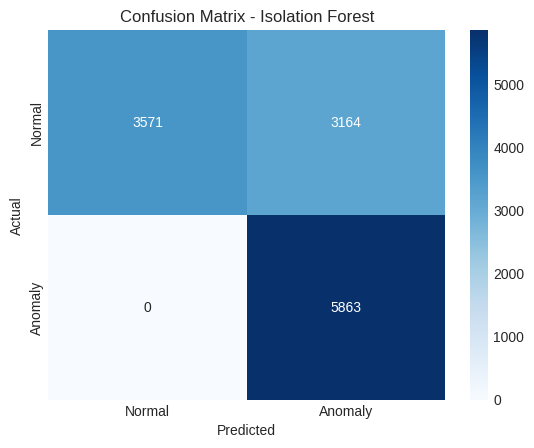

In [ ]:
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title("Confusion Matrix - Isolation Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
results_summary['IsolationForest'] = {
    'best_cv_roc_auc': None,
    'best_params': {
        'n_estimators': 150,
        'contamination': contamination,
        'random_state': 42
    },
    'val_roc_auc': roc,
    'val_f1_anomaly': f1,
    'training_time_total_gs': train_time,
    'estimator': iso_forest
}

In [ ]:
#joblib.dump(iso_forest, model_path)

## 7.7 Автоэнкодер

In [ ]:
X_train_norm = X_train[y_train == 0]
X_train_norm_proc = preprocessor.fit_transform(X_train_norm).astype('float32')
X_val_proc = preprocessor.transform(X_val).astype('float32')
y_val_np = y_val.values

In [ ]:
input_dim = X_train_norm_proc.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(encoded)
output_layer = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

start_time = time.time()
history = autoencoder.fit(
    X_train_norm_proc, X_train_norm_proc,
    epochs=100,
    batch_size=256,
    shuffle=True,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
train_time = time.time() - start_time
print(f"Время обучения автоэнкодера: {train_time:.2f} секунд")

Epoch 1/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3878 - val_loss: 0.2160
Epoch 2/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1290 - val_loss: 0.1511
Epoch 3/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0717 - val_loss: 0.1025
Epoch 4/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0405 - val_loss: 0.0828
Epoch 5/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0375 - val_loss: 0.0545
Epoch 6/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0470 - val_loss: 0.0379
Epoch 7/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0571 - val_loss: 0.0293
Epoch 8/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0272 - val_loss: 0.0315
Epoch 9/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0165 - val_loss: 0.0290
Epoch 10/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0165 - val_loss: 0.0340
Epoch 11/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0223 - val_loss: 0.0318
Epoch 12/100
214/214 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
recon_train = autoencoder.predict(X_train_norm_proc, batch_size=512)
mse_train = np.mean((X_train_norm_proc - recon_train) ** 2, axis=1)
threshold = np.percentile(mse_train, 95)
print(f"Порог восстановления (95 перцентиль): {threshold:.4f}")

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Порог восстановления (95 перцентиль): 0.0116


In [ ]:
recon_val = autoencoder.predict(X_val_proc, batch_size=512)
mse_val = np.mean((X_val_proc - recon_val) ** 2, axis=1)
y_val_pred = (mse_val > threshold).astype(int)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [ ]:
roc_ae = roc_auc_score(y_val_np, mse_val)
f1_ae = f1_score(y_val_np, y_val_pred)

print(f"ROC AUC: {roc_ae:.4f}")
print(f"F1 Score: {f1_ae:.4f}")
print(classification_report(y_val_np, y_val_pred))

ROC AUC: 0.9860
F1 Score: 0.9326
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      6735
           1       0.94      0.93      0.93      5863

    accuracy                           0.94     12598
   macro avg       0.94      0.94      0.94     12598
weighted avg       0.94      0.94      0.94     12598



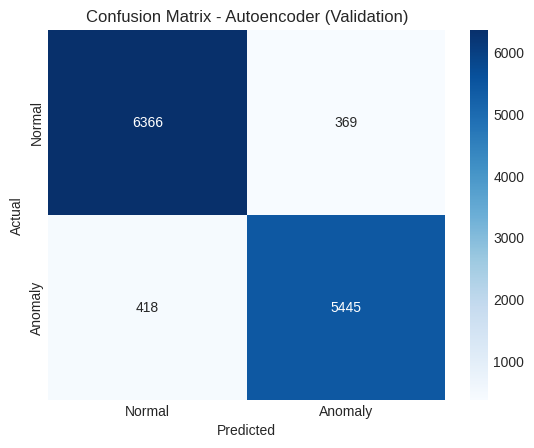

In [ ]:
cm = confusion_matrix(y_val_np, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title("Confusion Matrix - Autoencoder (Validation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
results_summary['Autoencoder'] = {
    'best_cv_roc_auc': None,
    'best_params': {
        'architecture': '64-32-64',
        'threshold_percentile': 95,
        'loss': 'mse',
        'optimizer': 'adam',
        'batch_size': 256,
        'early_stopping': True
    },
    'val_roc_auc': roc_ae,
    'val_f1_anomaly': f1_ae,
    'training_time_total_gs': train_time,
    'estimator': autoencoder,
}

In [ ]:
model_filename_ae = os.path.join(models_dir, "autoencoder_model.keras")

## 7.8 Полносвязная нейронная сеть (Multi-Layer Perceptron - MLP)

In [ ]:
# Нормализация и приведение типов
X_train_proc = preprocessor.fit_transform(X_train).astype('float32')
X_val_proc = preprocessor.transform(X_val).astype('float32')

y_train_np = y_train.values.astype('float32')
y_val_np = y_val.values.astype('float32')

input_dim_mlp = X_train_proc.shape[1]


In [ ]:
mlp_model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim_mlp,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

mlp_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

mlp_model.summary()

early_stopping_mlp = EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

start_time = time.time()
history_mlp = mlp_model.fit(
    X_train_proc, y_train_np,
    epochs=100,
    batch_size=128,
    validation_data=(X_val_proc, y_val_np),
    callbacks=[early_stopping_mlp],
    verbose=1
)
training_time_mlp = time.time() - start_time
print(f"Время обучения MLP: {training_time_mlp:.2f} сек")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │        15,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,857 (101.00 KB)

 Trainable params: 25,857 (101.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
886/886 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9478 - auc: 0.9809 - loss: 0.1439 - val_accuracy: 0.9926 - val_auc: 0.9997 - val_loss: 0.0223
Epoch 2/100
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9898 - auc: 0.9989 - loss: 0.0309 - val_accuracy: 0.9936 - val_auc: 0.9998 - val_loss: 0.0168
Epoch 3/100
886/886 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9917 - auc: 0.9992 - loss: 0.0254 - val_accuracy: 0.9944 - val_auc: 0.9998 - val_loss: 0.0155
Epoch 4/100
886/886 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9927 - auc: 0.9993 - loss: 0.0219 - val_accuracy: 0.9944 - val_auc: 0.9999 - val_loss: 0.0146
Epoch 5/100
886/886 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9933 - auc: 0.9996 - loss: 0.0187 - val_accuracy: 0.9944 - val_auc: 0.9999 - val_loss: 0.0146
Epoch 6/100
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9934 - auc: 0.9996 - loss: 0.0183 - val_accuracy: 0.9947 - val_auc: 0.9999 - val_loss: 0.0132
Epoch 7/100
886/886 ━━━━━━━━━━━━━━

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
ROC AUC: 1.0000
F1 Score: 0.9963
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      6735
         1.0       1.00      1.00      1.00      5863

    accuracy                           1.00     12598
   macro avg       1.00      1.00      1.00     12598
weighted avg       1.00      1.00      1.00     12598



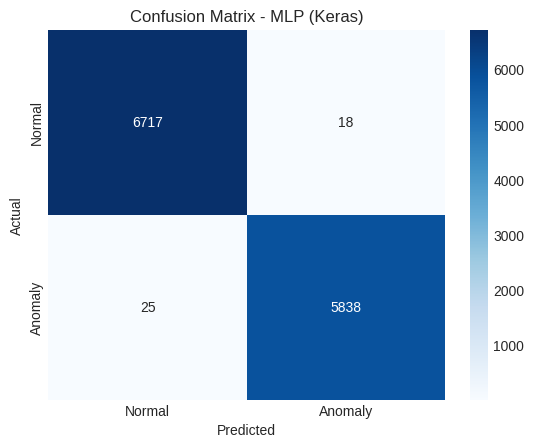

In [ ]:
y_val_pred_proba = mlp_model.predict(X_val_proc, batch_size=256).flatten()
y_val_pred = (y_val_pred_proba > 0.5).astype(int)

from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix

val_roc_auc_mlp = roc_auc_score(y_val_np, y_val_pred_proba)
val_f1_anomaly_mlp = f1_score(y_val_np, y_val_pred)

print(f"ROC AUC: {val_roc_auc_mlp:.4f}")
print(f"F1 Score: {val_f1_anomaly_mlp:.4f}")
print(classification_report(y_val_np, y_val_pred))

cm = confusion_matrix(y_val_np, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title("Confusion Matrix - MLP (Keras)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



In [ ]:
os.makedirs("saved_models", exist_ok=True)
mlp_path = "saved_models/mlp_keras.h5"
mlp_model.save(mlp_path)
print(f"MLP-модель сохранена в {mlp_path}")

results_summary['MLPClassifier'] = {
    'best_cv_roc_auc': None,
    'best_params': {
        'architecture': '128-64-32',
        'activation': 'relu',
        'dropout': 0.3,
        'optimizer': 'adam',
        'batch_size': 128,
        'early_stopping': True,
        'loss': 'binary_crossentropy'
    },
    'val_roc_auc': val_roc_auc_mlp,
    'val_f1_anomaly': val_f1_anomaly_mlp,
    'training_time_total_gs': training_time_mlp,
    'estimator': mlp_model,
    'model_path': mlp_path
}

# 8. Оценка и выбор лучших моделей.

In [150]:
results_df = pd.DataFrame.from_dict(results_summary, orient='index')

results_df = results_df.sort_values(by='val_roc_auc', ascending=False)

In [152]:
print("\nСводная таблица результатов моделей (валидационный набор):")
display(results_df[['val_roc_auc', 'val_f1_anomaly', 'training_time_total_gs', 'best_params']])



Сводная таблица результатов моделей (валидационный набор):


,val_roc_auc,val_f1_anomaly,training_time_total_gs,best_params
XGBoost,1.000,0.999,375.051,"{'clf__colsample_bytree': 0.7, 'clf__learning_..."
RandomForest,1.000,0.999,279.706,"{'clf__max_depth': None, 'clf__min_samples_lea..."
MLPClassifier,1.000,0.996,149.810,"{'architecture': '128-64-32', 'activation': 'r..."
LogisticRegression,0.997,0.972,377.684,"{'clf__C': 100, 'clf__solver': 'liblinear'}"
SGDClassifier,0.996,0.966,40.276,"{'clf__alpha': 0.0001, 'clf__loss': 'log_loss'..."
Autoencoder,0.986,0.933,44.407,"{'architecture': '64-32-64', 'threshold_percen..."
IsolationForest,0.981,0.788,0.745,"{'n_estimators': 150, 'contamination': 0.46542..."
GaussianNB,0.981,0.922,18.709,{'clf__var_smoothing': 0.0001}


In [153]:
top_models = results_df.head(3)
print("\nТри лучшие модели на валидации по ROC AUC:")
print(top_models[['val_roc_auc', 'val_f1_anomaly']])



Три лучшие модели на валидации по ROC AUC:
               val_roc_auc  val_f1_anomaly
XGBoost              1.000           0.999
RandomForest         1.000           0.999
MLPClassifier        1.000           0.996


# 9. Финально тестирование лучших моделей на data_test.

In [ ]:
X_test = data_test.drop(['anomaly', 'anomaly_bin', 'level'], axis=1)
y_test = data_test['anomaly'].values


In [155]:
def evaluate_model_on_test(name, model, X_test, y_test, keras=False):
    print(f"\n {name}")
    print("="*50)

    if keras:
        # Keras: применяем препроцессор вручную
        X_test_proc = preprocessor.transform(X_test).astype('float32')
        y_proba = model.predict(X_test_proc, batch_size=256).flatten()
        y_pred = (y_proba > 0.5).astype(int)
    else:
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    roc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)

    print(f"ROC AUC:  {roc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Anomaly'],
                yticklabels=['Normal', 'Anomaly'])
    plt.title(f"Confusion Matrix - {name} (Test Set)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


## 9.1 Тестирование XGBoost


 XGBoost
ROC AUC:  0.9670
F1 Score: 0.7870
              precision    recall  f1-score   support

           0       0.69      0.97      0.80      9711
           1       0.97      0.66      0.79     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.79     22544



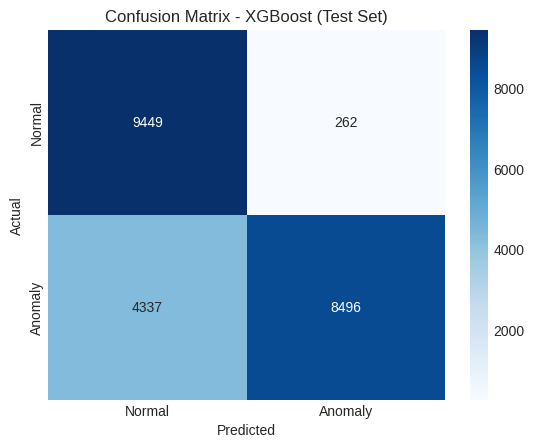

In [156]:
evaluate_model_on_test("XGBoost", results_summary['XGBoost']['estimator'], X_test, y_test)

## 9.2 Тестирование Random Forest


 RandomForest
ROC AUC:  0.9615
F1 Score: 0.7499
              precision    recall  f1-score   support

           0       0.65      0.97      0.78      9711
           1       0.97      0.61      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.79      0.77     22544
weighted avg       0.83      0.77      0.76     22544



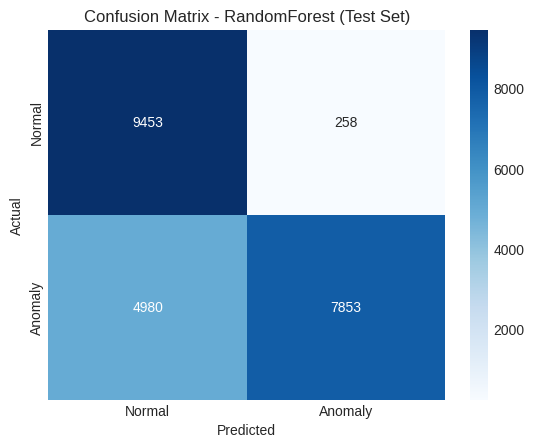

In [157]:
evaluate_model_on_test("RandomForest", results_summary['RandomForest']['estimator'], X_test, y_test)

## 9.3 Тестирование MLP


 MLPClassifier (Keras)
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
ROC AUC:  0.8866
F1 Score: 0.7917
              precision    recall  f1-score   support

           0       0.69      0.97      0.81      9711
           1       0.97      0.67      0.79     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.80     22544



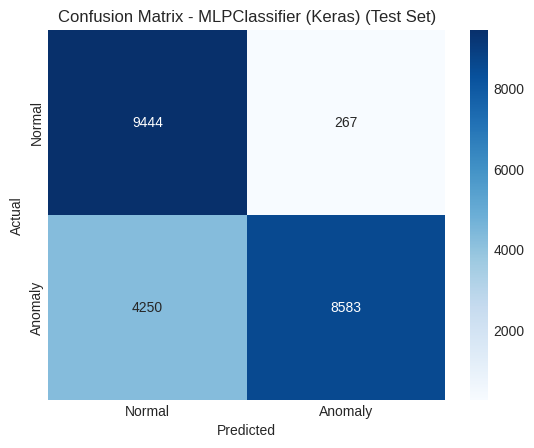

In [158]:
mlp_model_loaded = load_model(results_summary['MLPClassifier']['model_path'])
evaluate_model_on_test("MLPClassifier (Keras)", mlp_model_loaded, X_test, y_test, keras=True)


# 10. Анализ результатов.

## 10.1 Сводная таблица результатов финального тестирования

| Модель           | ROC AUC | F1-score | Recall (аномалии) | Recall (нормальные) |
| ---------------- | ------- | -------- | ----------------- | ------------------- |
| **XGBoost**      | 0.967   | 0.787    | **0.66**          | **0.97**            |
| **RandomForest** | 0.961   | 0.750    | 0.61              | 0.97                |
| **MLP (Keras)**  | 0.887   | 0.792    | **0.67**          | **0.97**            |


## 10.2 Обсуждение производительности лучших моделей

В рамках заключительного этапа были выбраны три модели, показавшие наивысшие значения метрик на валидационной выборке:  
**XGBoost**, **Random Forest** и **MLPClassifier** на Keras. Эти модели были протестированы на ранее не использовавшемся датасете `data_test` из KDDCup'99, что позволило объективно оценить их способность к обобщению.

### 🔹 XGBoost

Модель **XGBoost** показала наилучший результат по метрике **ROC AUC = 0.967**, демонстрируя отличную способность к ранжированию объектов по степени «аномальности».  
F1-мера составила **0.787**, что говорит о хорошем балансе между полнотой и точностью.  
Модель выявила **66% аномалий**, сохранив **97% корректных нормальных записей**, т.е. почти не допускает ложных срабатываний.

### 🔹 Random Forest

Модель **Random Forest** показала схожие, но немного более низкие результаты:  
- **ROC AUC = 0.961**
- **F1-score = 0.750**
- **Recall по аномалиям = 61%**

Это может быть критично в сценариях, где важно не упустить ни одной потенциальной угрозы.  
Тем не менее, точность и высокая полнота по нормальным событиям (97%) указывают на стабильность модели.

### 🔹 MLPClassifier (Keras)

Нейросетевой классификатор **MLPClassifier** (на Keras) достиг наивысшей **F1-метрики — 0.792**,  
однако **ROC AUC оказался ниже — 0.887**, что означает менее уверенное ранжирование.  
При этом модель продемонстрировала:
- **Полноту по аномалиям = 67%** — наивысшую среди всех моделей,
- **Полноту по нормальным = 97%** — как и у остальных.

Это делает MLPClassifier полезным в задачах, где важно поймать как можно больше атак, даже ценой небольшого количества ложных срабатываний.

---

### ✅ Выводы

- **XGBoost** — наиболее сбалансированная и надёжная модель для задач обнаружения аномалий.
- **MLPClassifier** — предпочтителен, если ключевая задача — максимальное покрытие атак (высокий recall).
- **Random Forest** — хорошая базовая модель, но уступает другим по ключевым метрикам.

Сравнение трёх подходов — градиентного бустинга, ансамблей деревьев и нейросетей — подтвердило, что даже без глубоких архитектур можно достигать высокой точности при качественной обработке данных.


## 10.3 Итоговые выводы по практической работе

В рамках курсовой работы была решена задача обнаружения аномалий в сетевом трафике с использованием различных алгоритмов машинного обучения. В качестве исходных данных использовался датасет KDDCup'99, который был предварительно очищен, сбалансирован и подготовлен для обучения моделей.

На этапе анализа данных были проведены:  
- первичный осмотр и визуализация признаков,  
- кодирование категориальных переменных,  
- масштабирование числовых признаков с помощью `StandardScaler`,  
- разбиение выборки на тренировочную, валидационную и тестовую части.

Были обучены и протестированы следующие группы моделей:
- **Классические модели классификации**: Logistic Regression, Naive Bayes, Support Vector Machine;
- **Ансамблевые методы**: Random Forest, XGBoost;
- **Методы выявления аномалий без учителя**: Isolation Forest, Autoencoder;
- **Нейросетевые методы**: MLPClassifier на Keras.

После оценки моделей на валидационном наборе были выбраны три лучших по метрике ROC AUC:  
**XGBoost**, **Random Forest** и **MLPClassifier**. Эти модели были дополнительно протестированы на независимом тестовом наборе `data_test`, что позволило объективно оценить их способность к обобщению.

Наилучшие результаты показал **XGBoost**, достигнув ROC AUC = 0.967 и F1-score = 0.787. Модель MLPClassifier на Keras оказалась наиболее чувствительной к аномалиям, показав F1 = 0.792 при ROC AUC = 0.887. Random Forest занял промежуточную позицию по метрикам, продемонстрировав хорошую точность и скорость обучения.

Таким образом, можно сделать вывод, что ансамблевые и нейросетевые методы показывают высокую эффективность в задачах обнаружения аномалий, особенно при наличии качественной предобработки и сбалансированной выборки.  
Разработанный пайплайн позволяет гибко подключать новые модели и применять его к другим задачам кибербезопасности.

В дальнейшем возможными направлениями развития проекта являются:
- использование более современных датасетов (например, UNSW-NB15 или CICIDS);
- добавление временных признаков и анализ последовательностей атак;
- реализация ансамблей моделей (stacking, voting) для повышения устойчивости решений.


# 11. Список литературы

1. Каскырбаева К.С. Применение методов машинного обучения для выявления аномалий в сетевом трафике // Вестник науки. – 2023.
2. UCI Machine Learning Repository: KDD Cup 1999 Data. URL: https://kdd.ics.uci.edu/databases/kddcup99/kddcup99.html (Официальная страница датасета KDD Cup '99).
3. Canadian Institute for Cybersecurity: NSL-KDD Dataset. URL: https://www.unb.ca/cic/datasets/nsl.html (Информация по датасету NSL-KDD, а в частности KDDTrain+/KDDTest+).
4. Scikit-learn: Machine Learning in Python. URL: https://scikit-learn.org/ (Документация по основной используемой библиотеке).

5. TensorFlow Documentation. URL: https://www.tensorflow.org/ (Для Автоэнкодера и MLP).

6. XGBoost Documentation. URL: https://xgboost.readthedocs.io/ (Документация по XGBoost).

7. Pandas: Python Data Analysis Library. URL: https://pandas.pydata.org/